# Load The Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load data
train = pd.read_csv(r"C:\Users\Acer Nitro\Desktop\NewWork\DataSet\train.csv")
test = pd.read_csv(r"C:\Users\Acer Nitro\Desktop\NewWork\DataSet\test.csv")
meta = pd.read_csv(r"C:\Users\Acer Nitro\Desktop\NewWork\DataSet\metaData.csv")
sample = pd.read_csv(r"C:\Users\Acer Nitro\Desktop\NewWork\DataSet\sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (221, 37)
Test shape: (95, 35)


,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,0.000000,0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,0.000000,0.000000,21,5,7,44.990274,0


In [28]:
#نسخ من الداتا الأصلية
train_df = train.copy()
test_df= test.copy()
meta_df= meta.copy()
sample_sub_df = sample.copy()



In [29]:
#حددت الأعمدة المهمة
TARGET_TIME = "time_to_hit_hours"
TARGET_EVENT = "event"
ID_COL = "event_id"

In [30]:
# (time_to_hit_hours,event,event_id)بإستثناء Features جبت كل الأعمدة اللي رح أعتبرها
feature_cols = [c for c in train.columns if c not in [ID_COL, TARGET_TIME, TARGET_EVENT]]
feature_cols

['num_perimeters_0_5h',
 'dt_first_last_0_5h',
 'low_temporal_resolution_0_5h',
 'area_first_ha',
 'area_growth_abs_0_5h',
 'area_growth_rel_0_5h',
 'area_growth_rate_ha_per_h',
 'log1p_area_first',
 'log1p_growth',
 'log_area_ratio_0_5h',
 'relative_growth_0_5h',
 'radial_growth_m',
 'radial_growth_rate_m_per_h',
 'centroid_displacement_m',
 'centroid_speed_m_per_h',
 'spread_bearing_deg',
 'spread_bearing_sin',
 'spread_bearing_cos',
 'dist_min_ci_0_5h',
 'dist_std_ci_0_5h',
 'dist_change_ci_0_5h',
 'dist_slope_ci_0_5h',
 'closing_speed_m_per_h',
 'closing_speed_abs_m_per_h',
 'projected_advance_m',
 'dist_accel_m_per_h2',
 'dist_fit_r2_0_5h',
 'alignment_cos',
 'alignment_abs',
 'cross_track_component',
 'along_track_speed',
 'event_start_hour',
 'event_start_dayofweek',
 'event_start_month']

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_id                      221 non-null    int64  
 1   num_perimeters_0_5h           221 non-null    int64  
 2   dt_first_last_0_5h            221 non-null    float64
 3   low_temporal_resolution_0_5h  221 non-null    int64  
 4   area_first_ha                 221 non-null    float64
 5   area_growth_abs_0_5h          221 non-null    float64
 6   area_growth_rel_0_5h          221 non-null    float64
 7   area_growth_rate_ha_per_h     221 non-null    float64
 8   log1p_area_first              221 non-null    float64
 9   log1p_growth                  221 non-null    float64
 10  log_area_ratio_0_5h           221 non-null    float64
 11  relative_growth_0_5h          221 non-null    float64
 12  radial_growth_m               221 non-null    float64
 13  radia

In [4]:
train.describe()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
count,2.210000e+02,221.000000,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000,221.000000,...,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000
mean,5.384397e+07,2.063348,0.979869,0.728507,619.131641,26.332398,1.789087e-01,6.167128,4.683276,0.389346,...,0.046000,-0.004971,0.172704,1.617188,0.551690,15.429864,2.841629,6.782805,37.567626,0.312217
std,2.507456e+07,2.578859,1.738052,0.445739,1447.723668,187.437018,1.302001e+00,40.467370,2.083529,1.340348,...,0.171690,0.371909,0.329210,37.789199,46.760648,7.921250,1.974217,1.571876,25.902361,0.464450
min,1.089246e+07,1.000000,0.000000,0.000000,0.037525,-0.000022,-1.440000e-07,-0.000005,0.036838,0.000000,...,0.000000,-0.999995,0.000000,-213.411731,-526.597241,0.000000,0.000000,1.000000,0.001220,0.000000
25%,3.209326e+07,1.000000,0.000000,0.000000,25.219058,0.000000,0.000000e+00,0.000000,3.266487,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,6.000000,12.242322,0.000000
50%,5.244094e+07,1.000000,0.000000,1.000000,110.149250,0.000000,0.000000e+00,0.000000,4.710874,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,3.000000,7.000000,43.109830,0.000000
75%,7.457274e+07,2.000000,1.356107,1.000000,485.092561,0.000000,0.000000e+00,0.000000,6.186399,0.000000,...,0.000000,0.000000,0.071697,0.000000,0.000000,21.000000,5.000000,8.000000,63.938706,1.000000
max,9.933973e+07,17.000000,4.994457,1.000000,11942.392110,2508.041442,1.788970e+01,520.443033,9.387933,7.827656,...,0.917415,0.994594,0.999995,277.110446,383.099186,23.000000,6.000000,9.000000,66.994474,1.000000


In [5]:
train["event"].value_counts()

event
0    152
1     69
Name: count, dtype: int64

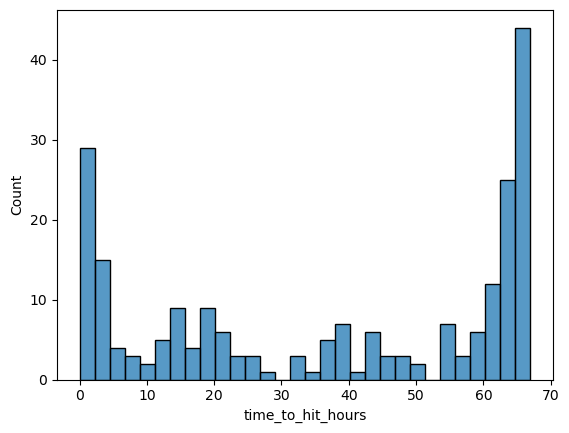

In [8]:
sns.histplot(train["time_to_hit_hours"], bins=30)
plt.show()

In [10]:
#هاي دالة تبني جدول ملخص لكل الأعمدة

def build_summary_table(df):
  summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str), #نوع كل عمود
    "missing_count": df.isna().sum(), #عدد القيم المفقودة
    "missing_pct": df.isna().mean() * 100, #نسبة القيم المفقودة
    "n_unique": df.nunique(dropna=False)}) #عدد القيم الفريدة في العمود

  # عشان أول شيء نشوف الأعمدة اللي فيها مشاكل , unique ثم أقل missing يرتب الجدول حسب أعلى
  return summary.sort_values(["missing_pct", "n_unique"], ascending=[False, True])
summary_table = build_summary_table(train)
print(summary_table)

                                dtype  missing_count  missing_pct  n_unique
low_temporal_resolution_0_5h    int64              0          0.0         2
event                           int64              0          0.0         2
event_start_dayofweek           int64              0          0.0         7
event_start_month               int64              0          0.0         9
num_perimeters_0_5h             int64              0          0.0        12
dist_change_ci_0_5h           float64              0          0.0        19
closing_speed_m_per_h         float64              0          0.0        19
closing_speed_abs_m_per_h     float64              0          0.0        19
projected_advance_m           float64              0          0.0        19
dist_std_ci_0_5h              float64              0          0.0        20
dist_fit_r2_0_5h              float64              0          0.0        20
event_start_hour                int64              0          0.0        22
log1p_growth

In [11]:
'''يعطينا إحصائيات وصفية للأعمدة الرقمية
count,mean,std,min,quartiles,max
'''
def numeric_summary(df, cols):
    return df[cols].describe().T.sort_index()

# Utility functions

In [17]:
# نكتب دالة ونستخدمها مرتين ,(train والـ test) عشان بدل ما نكرر نفس الكود لل

def dataset_overview(df, name="Dataset"):
  # بشكل مرتب للداتا shape بيعرض عنوان و بعرض عنوان مرتب و بعرض عنوان و
  print(f"\n{'='*70}")
  print(f"{name} OVERVIEW")
  print(f"{'='*70}")
  print("Shape:", df.shape)

  # بعرض عدد أنواع الأعمدة, مهم عشان أعرف طبيعة الداتا عندي
  print("\nDtypes:")
  display(df.dtypes.value_counts())

  # بيعرض أول 5 صفوف
  print("\nFirst 5 rows:")
  display(df.head())

  '''بفحص كل خلية إذا مفقودة أو لا
  وبعدها بجمع عدد القيم المفقودة بكل عمود وكمان برتب الأعمدة من الأكثر قيم مققودة للأقل
  وآخر شي بيجيب فقط الأعمدة اللي فيها 20 فيمة مفقودةوأعلى
  '''
  print("\nMissing values (top 20):")
  missing = df.isna().sum().sort_values(ascending=False)
  display(missing[missing > 0].head(20))

  #بعدّ الصفوف المكررة
  print("\nDuplicate rows:", df.duplicated().sum())

In [31]:
numeric_cols = train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

categorical_cols = train[feature_cols].select_dtypes(exclude=[np.number]).columns.tolist()


In [32]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Number of features:", len(feature_cols))
print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

Train shape: (221, 37)
Test shape: (95, 35)
Number of features: 34
Numeric features: 34
Categorical features: 0


In [14]:
dataset_overview(train, "TRAIN")
dataset_overview(test, "TEST")


TRAIN DATASET OVERVIEW
Shape: (221, 37)

Data Types:
event_id                          int64
num_perimeters_0_5h               int64
dt_first_last_0_5h              float64
low_temporal_resolution_0_5h      int64
area_first_ha                   float64
area_growth_abs_0_5h            float64
area_growth_rel_0_5h            float64
area_growth_rate_ha_per_h       float64
log1p_area_first                float64
log1p_growth                    float64
log_area_ratio_0_5h             float64
relative_growth_0_5h            float64
radial_growth_m                 float64
radial_growth_rate_m_per_h      float64
centroid_displacement_m         float64
centroid_speed_m_per_h          float64
spread_bearing_deg              float64
spread_bearing_sin              float64
spread_bearing_cos              float64
dist_min_ci_0_5h                float64
dist_std_ci_0_5h                float64
dist_change_ci_0_5h             float64
dist_slope_ci_0_5h              float64
closing_speed_m_per_h     

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,0.000000,0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,0.000000,0.000000,21,5,7,44.990274,0



TEST DATASET OVERVIEW
Shape: (95, 35)

Data Types:
event_id                          int64
num_perimeters_0_5h               int64
dt_first_last_0_5h              float64
low_temporal_resolution_0_5h      int64
area_first_ha                   float64
area_growth_abs_0_5h            float64
area_growth_rel_0_5h            float64
area_growth_rate_ha_per_h       float64
log1p_area_first                float64
log1p_growth                    float64
log_area_ratio_0_5h             float64
relative_growth_0_5h            float64
radial_growth_m                 float64
radial_growth_rate_m_per_h      float64
centroid_displacement_m         float64
centroid_speed_m_per_h          float64
spread_bearing_deg              float64
spread_bearing_sin              float64
spread_bearing_cos              float64
dist_min_ci_0_5h                float64
dist_std_ci_0_5h                float64
dist_change_ci_0_5h             float64
dist_slope_ci_0_5h              float64
closing_speed_m_per_h       

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month
0,10662602,1,0.000000,1,2.452217,0.000000,0.00000,0.000000,1.239017,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,3,7
1,13353600,1,0.000000,1,131.669588,0.000000,0.00000,0.000000,4.887862,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,22,0,8
2,13942327,1,0.000000,1,6.723104,0.000000,0.00000,0.000000,2.044216,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,2,6,7
3,16112781,1,0.000000,1,285.416736,0.000000,0.00000,0.000000,5.657448,0.000000,...,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0,1,7
4,17132808,7,3.459331,0,61.098604,12.516633,0.20486,3.618224,4.128724,2.603921,...,13.54413,-22.687575,0.044572,0.15855,0.15855,-24.414806,3.920562,23,5,7


# Summary tables

In [19]:
train_summary = build_summary_table(train)
test_summary = build_summary_table(test)
display(train_summary)


,dtype,missing_count,missing_pct,n_unique
low_temporal_resolution_0_5h,int64,0,0.0,2
event,int64,0,0.0,2
event_start_dayofweek,int64,0,0.0,7
event_start_month,int64,0,0.0,9
num_perimeters_0_5h,int64,0,0.0,12
dist_change_ci_0_5h,float64,0,0.0,19
closing_speed_m_per_h,float64,0,0.0,19
closing_speed_abs_m_per_h,float64,0,0.0,19
projected_advance_m,float64,0,0.0,19
dist_std_ci_0_5h,float64,0,0.0,20


In [20]:
display(test_summary)

,dtype,missing_count,missing_pct,n_unique
low_temporal_resolution_0_5h,int64,0,0.0,2
dist_change_ci_0_5h,float64,0,0.0,6
closing_speed_m_per_h,float64,0,0.0,6
closing_speed_abs_m_per_h,float64,0,0.0,6
projected_advance_m,float64,0,0.0,6
dist_fit_r2_0_5h,float64,0,0.0,6
dist_std_ci_0_5h,float64,0,0.0,7
event_start_dayofweek,int64,0,0.0,7
area_growth_abs_0_5h,float64,0,0.0,8
area_growth_rel_0_5h,float64,0,0.0,8


In [33]:
display(numeric_summary(train, numeric_cols))

,count,mean,std,min,25%,50%,75%,max
alignment_abs,221.0,0.172704,0.329210,0.000000e+00,0.000000,0.000000,0.071697,0.999995
alignment_cos,221.0,-0.004971,0.371909,-9.999948e-01,0.000000,0.000000,0.000000,0.994594
along_track_speed,221.0,0.551690,46.760648,-5.265972e+02,0.000000,0.000000,0.000000,383.099186
area_first_ha,221.0,619.131641,1447.723668,3.752484e-02,25.219058,110.149250,485.092561,11942.392110
area_growth_abs_0_5h,221.0,26.332398,187.437018,-2.160000e-05,0.000000,0.000000,0.000000,2508.041442
area_growth_rate_ha_per_h,221.0,6.167128,40.467370,-5.290000e-06,0.000000,0.000000,0.000000,520.443033
area_growth_rel_0_5h,221.0,0.178909,1.302001,-1.440000e-07,0.000000,0.000000,0.000000,17.889695
centroid_displacement_m,221.0,44.277876,218.759628,0.000000e+00,0.000000,0.000000,0.000000,2045.333109
centroid_speed_m_per_h,221.0,11.953522,58.940466,0.000000e+00,0.000000,0.000000,0.000000,595.058697
closing_speed_abs_m_per_h,221.0,3.661135,26.690409,0.000000e+00,0.000000,0.000000,0.000000,354.120897


# Check target

In [34]:
'''
عشان نعرف هل الداتا عندي متوازنة ولا لا , لانه اذا معظم القيم 1 وقليل 0 هاي معلومات مهمة للموديل ,event بعد كم مرة كل قيمة ظهرت في

'''
print("Event value counts:")
display(train[TARGET_EVENT].value_counts(dropna=False))

#يعطينا النسبة المئوية بدل العدد
print("\nEvent percentage:")
display(train[TARGET_EVENT].value_counts(normalize=True, dropna=False) * 100)

# إحصائيات الهدف
print("\nTime-to-hit summary:")
display(train[TARGET_TIME].describe())

Event value counts:


event
0    152
1     69
Name: count, dtype: int64


Event percentage:


event
0    68.778281
1    31.221719
Name: proportion, dtype: float64


Time-to-hit summary:


count    221.000000
mean      37.567626
std       25.902361
min        0.001220
25%       12.242322
50%       43.109830
75%       63.938706
max       66.994474
Name: time_to_hit_hours, dtype: float64

<Axes: xlabel='event', ylabel='count'>

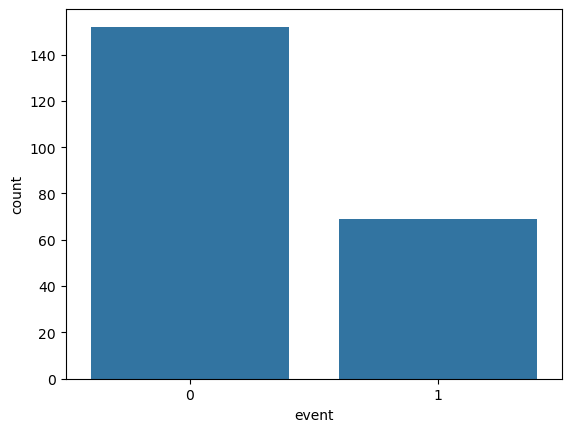

In [35]:
# event رسم يوضح توازن الـ
sns.countplot(data=train, x=TARGET_EVENT)

<Axes: xlabel='time_to_hit_hours', ylabel='Count'>

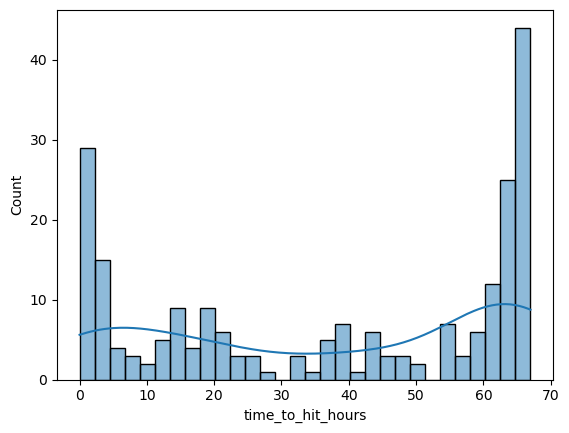

In [36]:
#time_to_hit_hours يرسم توزيع
sns.histplot(train[TARGET_TIME], bins=30, kde=True)

<Axes: xlabel='time_to_hit_hours'>

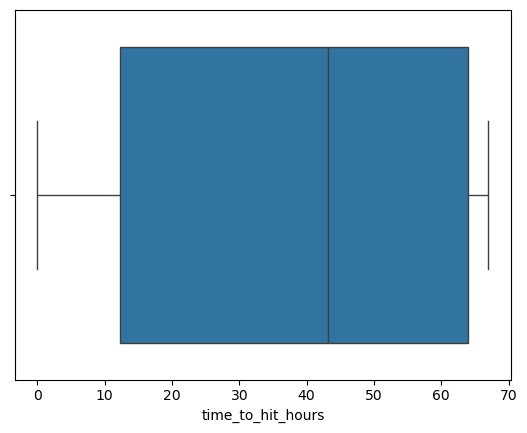

In [37]:
#عشان نكشف القيم الشاذة بسرعة
sns.boxplot(x=train[TARGET_TIME])

<Axes: xlabel='event', ylabel='time_to_hit_hours'>

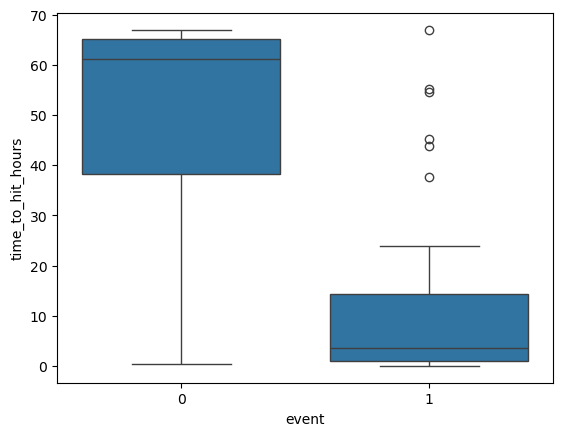

In [38]:
#بقارن الوقت حسب وجود الحدث أو عدمه
sns.boxplot(data=train, x=TARGET_EVENT, y=TARGET_TIME)

# Metadata merge for understanding columns

In [39]:
display(meta)

,column,type,category,description,units,range
0,event_id,identifier,identifier,Anonymized fire event identifier (stable rando...,NaN,NaN
1,time_to_hit_hours,target,target,Time from t0+5h until fire comes within 5km of...,hours,"[0, 72]"
2,event,target,target,"Event indicator: 1 if fire hit within 72h, 0 i...",NaN,NaN
3,num_perimeters_0_5h,feature,temporal_coverage,Number of perimeters within first 5 hours,NaN,NaN
4,dt_first_last_0_5h,feature,temporal_coverage,Time span between first and last perimeter (ho...,NaN,NaN
5,low_temporal_resolution_0_5h,feature,temporal_coverage,"Flag: 1 if dt < 0.5h or only 1 perimeter, else 0",NaN,NaN
6,area_first_ha,feature,growth,Initial fire area at t0 (hectares),NaN,NaN
7,area_growth_abs_0_5h,feature,growth,Feature from growth category,NaN,NaN
8,area_growth_rel_0_5h,feature,growth,Feature from growth category,NaN,NaN
9,area_growth_rate_ha_per_h,feature,growth,Area growth rate (hectares per hour),NaN,NaN


In [40]:
#category/type بعرض عدد الأعمدة في كل
display(meta["category"].value_counts(dropna=False))
display(meta["type"].value_counts(dropna=False))

category
growth                 10
distance                9
centroid_kinematics     5
directionality          4
temporal_coverage       3
temporal_metadata       3
target                  2
identifier              1
Name: count, dtype: int64

type
feature       34
target         2
identifier     1
Name: count, dtype: int64

In [41]:
'''
ويعرض features يأخذ فقط الصفوف اللي هي
اسم العمود
فئته
وصفه
'''
meta_features = meta[meta["type"] == "feature"].copy()
display(meta_features[["column", "category", "description"]].sort_values(["category", "column"]))

,column,category,description
16,centroid_displacement_m,centroid_kinematics,Feature from centroid_kinematics category
17,centroid_speed_m_per_h,centroid_kinematics,Feature from centroid_kinematics category
20,spread_bearing_cos,centroid_kinematics,Feature from centroid_kinematics category
18,spread_bearing_deg,centroid_kinematics,Feature from centroid_kinematics category
19,spread_bearing_sin,centroid_kinematics,Feature from centroid_kinematics category
31,alignment_abs,directionality,Absolute alignment between fire motion and eva...
30,alignment_cos,directionality,Feature from directionality category
33,along_track_speed,directionality,Feature from directionality category
32,cross_track_component,directionality,Feature from directionality category
26,closing_speed_abs_m_per_h,distance,Feature from distance category


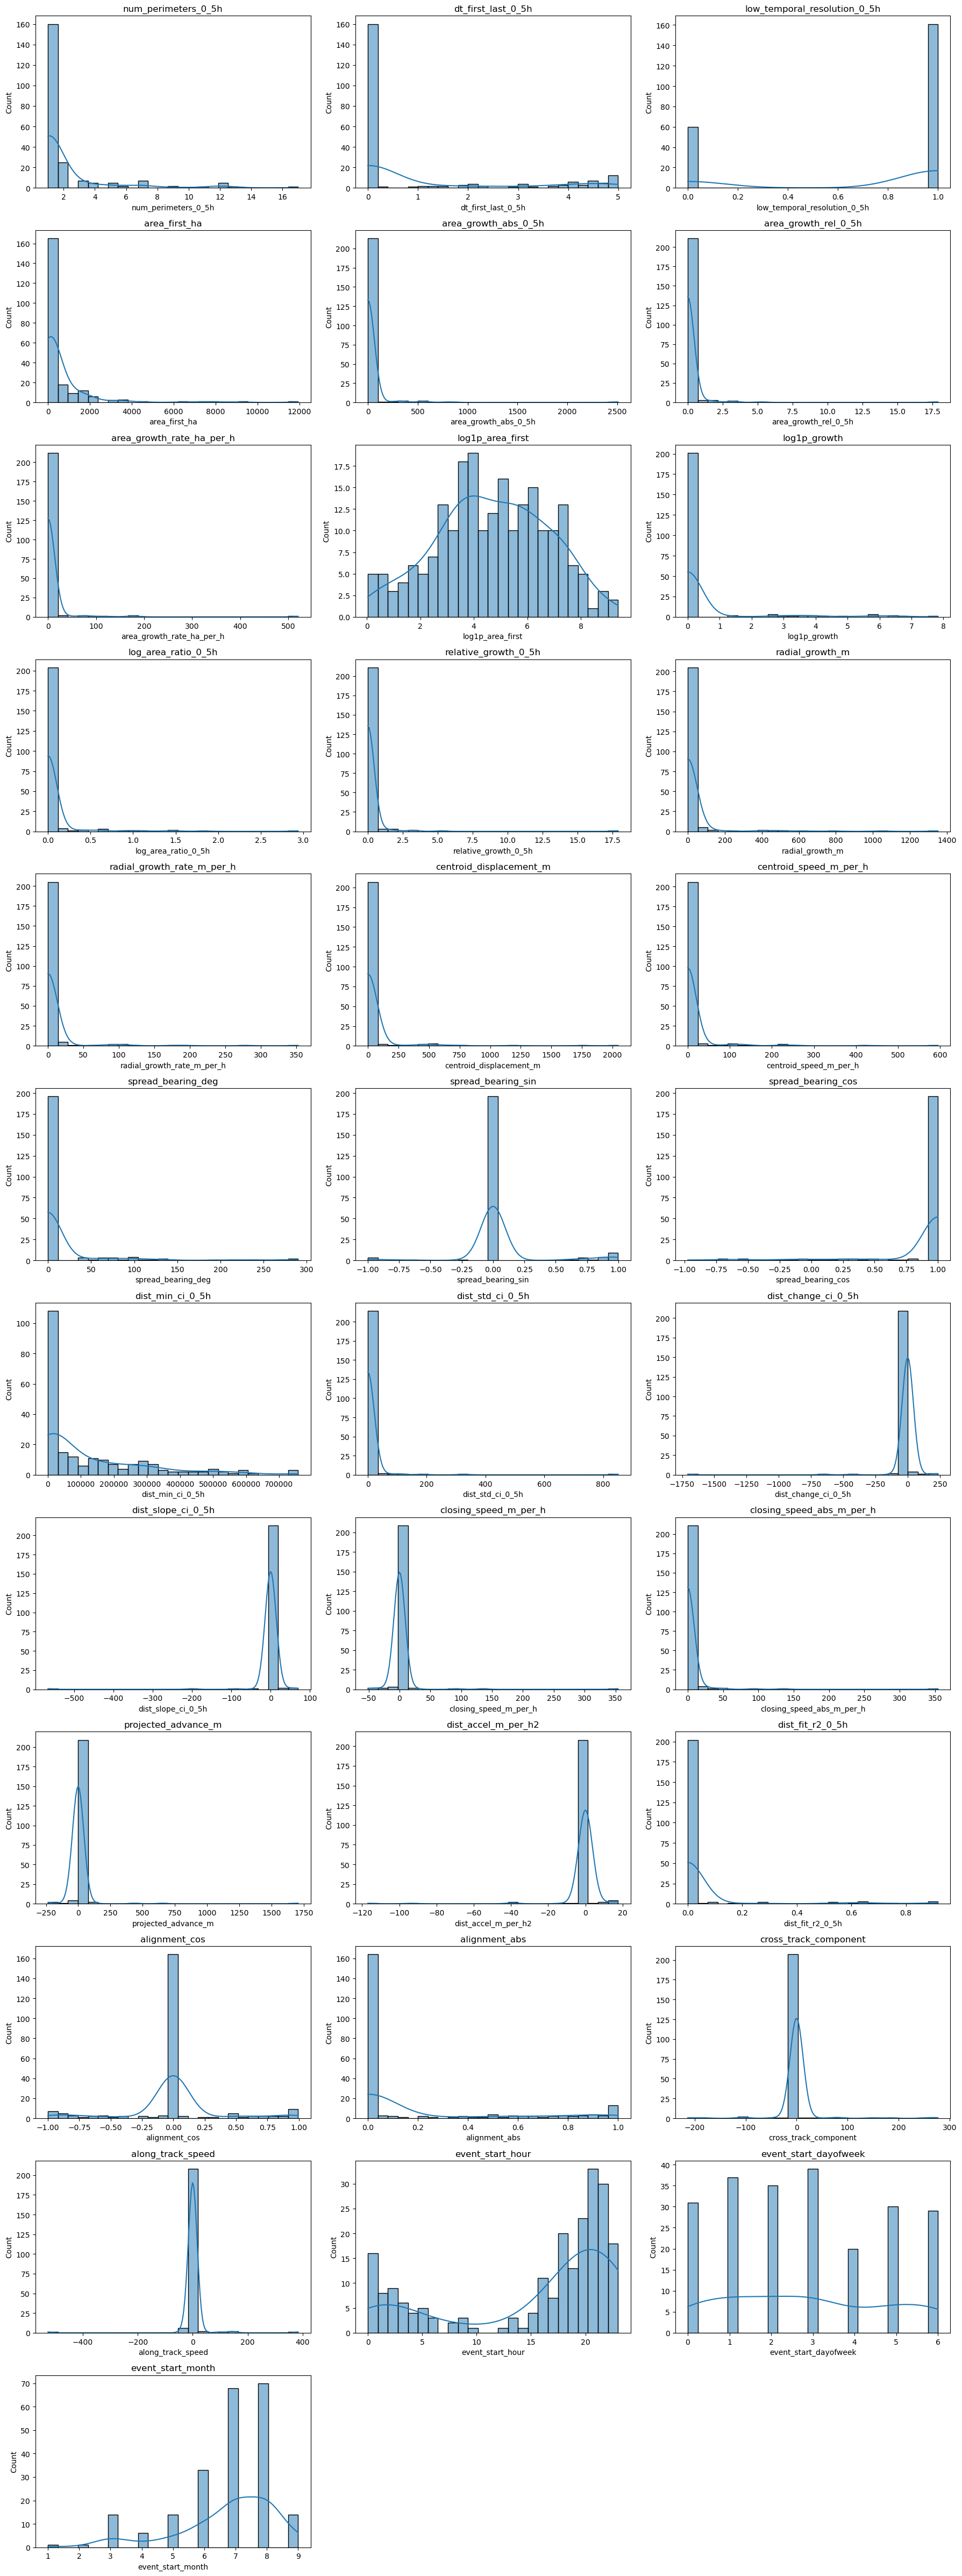

In [42]:
# لكل الأعمدة الرقمية distributions هاي دالة ترسم
def plot_numeric_distributions(df, cols, n_cols=3, bins=30, figsize_per_row=4):
  #يحسب كم صف من الرسومات بدنا
  n = len(cols)
  n_rows = int(np.ceil(n / n_cols))

  #يضبط حجم الشكل حسب عدد الرسومات
  plt.figure(figsize=(n_cols * 6, n_rows * figsize_per_row))

  #يرسم histogram لكل عمود
  for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], bins=bins, kde=True)
    plt.title(col)

  plt.tight_layout()
  plt.show()

plot_numeric_distributions(train, numeric_cols, n_cols=3, bins=25, figsize_per_row=4)

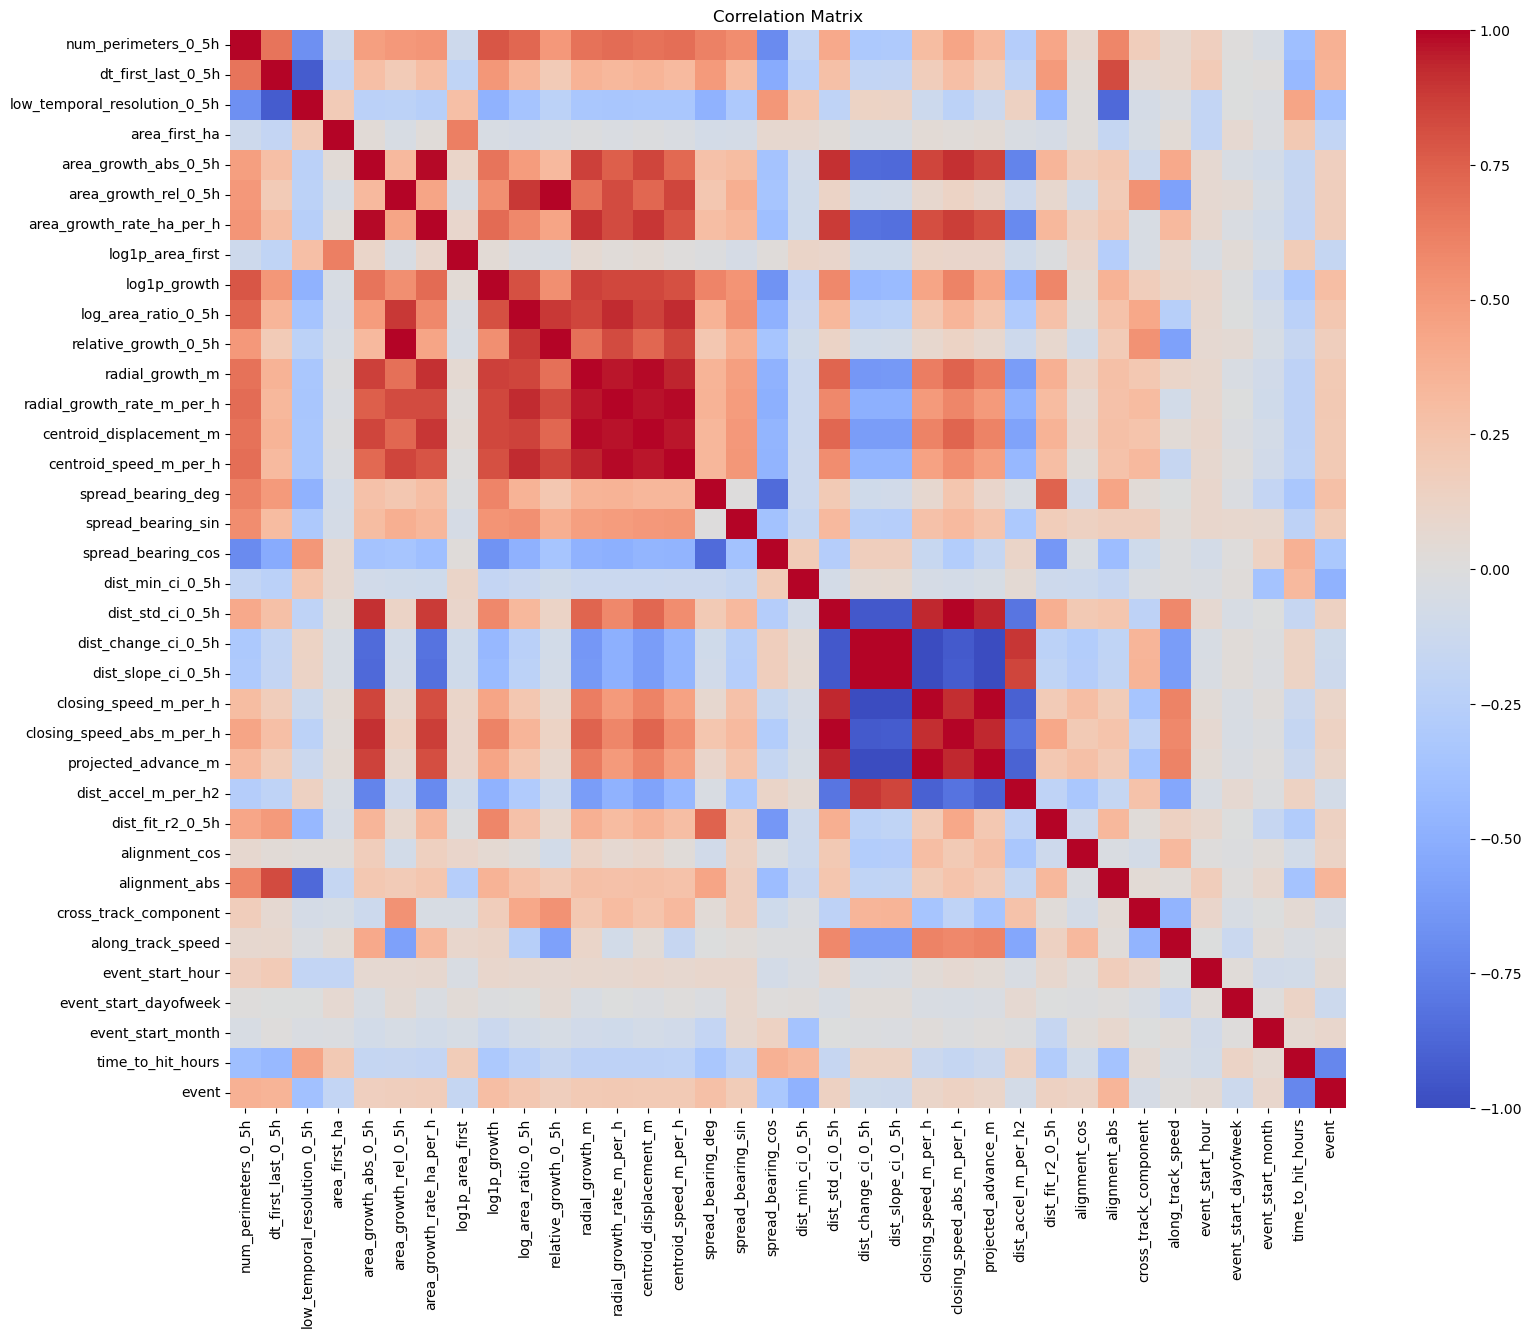

In [44]:
#بين الأعمدة الرقمية والهدفين correlation matrix يحساب
corr = train[numeric_cols + [TARGET_TIME, TARGET_EVENT]].corr(numeric_only=True)

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [45]:
# Target مع ال correlations أعلى
corr_time = corr[TARGET_TIME].drop(TARGET_TIME).sort_values(key=np.abs, ascending=False)
corr_event = corr[TARGET_EVENT].drop(TARGET_EVENT).sort_values(key=np.abs, ascending=False)

#مرشحة للموديل features عشان نطلع أول قائمة
print("Top correlations with time_to_hit_hours:")
display(corr_time.head(20))

print("Top correlations with event:")
display(corr_event.head(20))

Top correlations with time_to_hit_hours:


event                          -0.719485
low_temporal_resolution_0_5h    0.442236
dt_first_last_0_5h             -0.434699
num_perimeters_0_5h            -0.392040
spread_bearing_cos              0.370451
alignment_abs                  -0.366923
spread_bearing_deg             -0.335598
dist_min_ci_0_5h                0.324876
log1p_growth                   -0.317451
dist_fit_r2_0_5h               -0.284143
log_area_ratio_0_5h            -0.228119
radial_growth_rate_m_per_h     -0.218137
radial_growth_m                -0.217379
centroid_displacement_m        -0.212354
spread_bearing_sin             -0.211706
area_first_ha                   0.211212
centroid_speed_m_per_h         -0.208943
log1p_area_first                0.192067
area_growth_rate_ha_per_h      -0.177191
closing_speed_abs_m_per_h      -0.166876
Name: time_to_hit_hours, dtype: float64

Top correlations with event:


time_to_hit_hours              -0.719485
dist_min_ci_0_5h               -0.481379
low_temporal_resolution_0_5h   -0.379117
num_perimeters_0_5h             0.370501
dt_first_last_0_5h              0.352954
alignment_abs                   0.349115
spread_bearing_cos             -0.323189
log1p_growth                    0.292688
spread_bearing_deg              0.281012
log_area_ratio_0_5h             0.229327
radial_growth_rate_m_per_h      0.214956
radial_growth_m                 0.209343
centroid_speed_m_per_h          0.209254
centroid_displacement_m         0.207992
spread_bearing_sin              0.188252
area_first_ha                  -0.181334
area_growth_rate_ha_per_h       0.172416
log1p_area_first               -0.167912
area_growth_rel_0_5h            0.165975
relative_growth_0_5h            0.165975
Name: event, dtype: float64

# Feature vs target plots

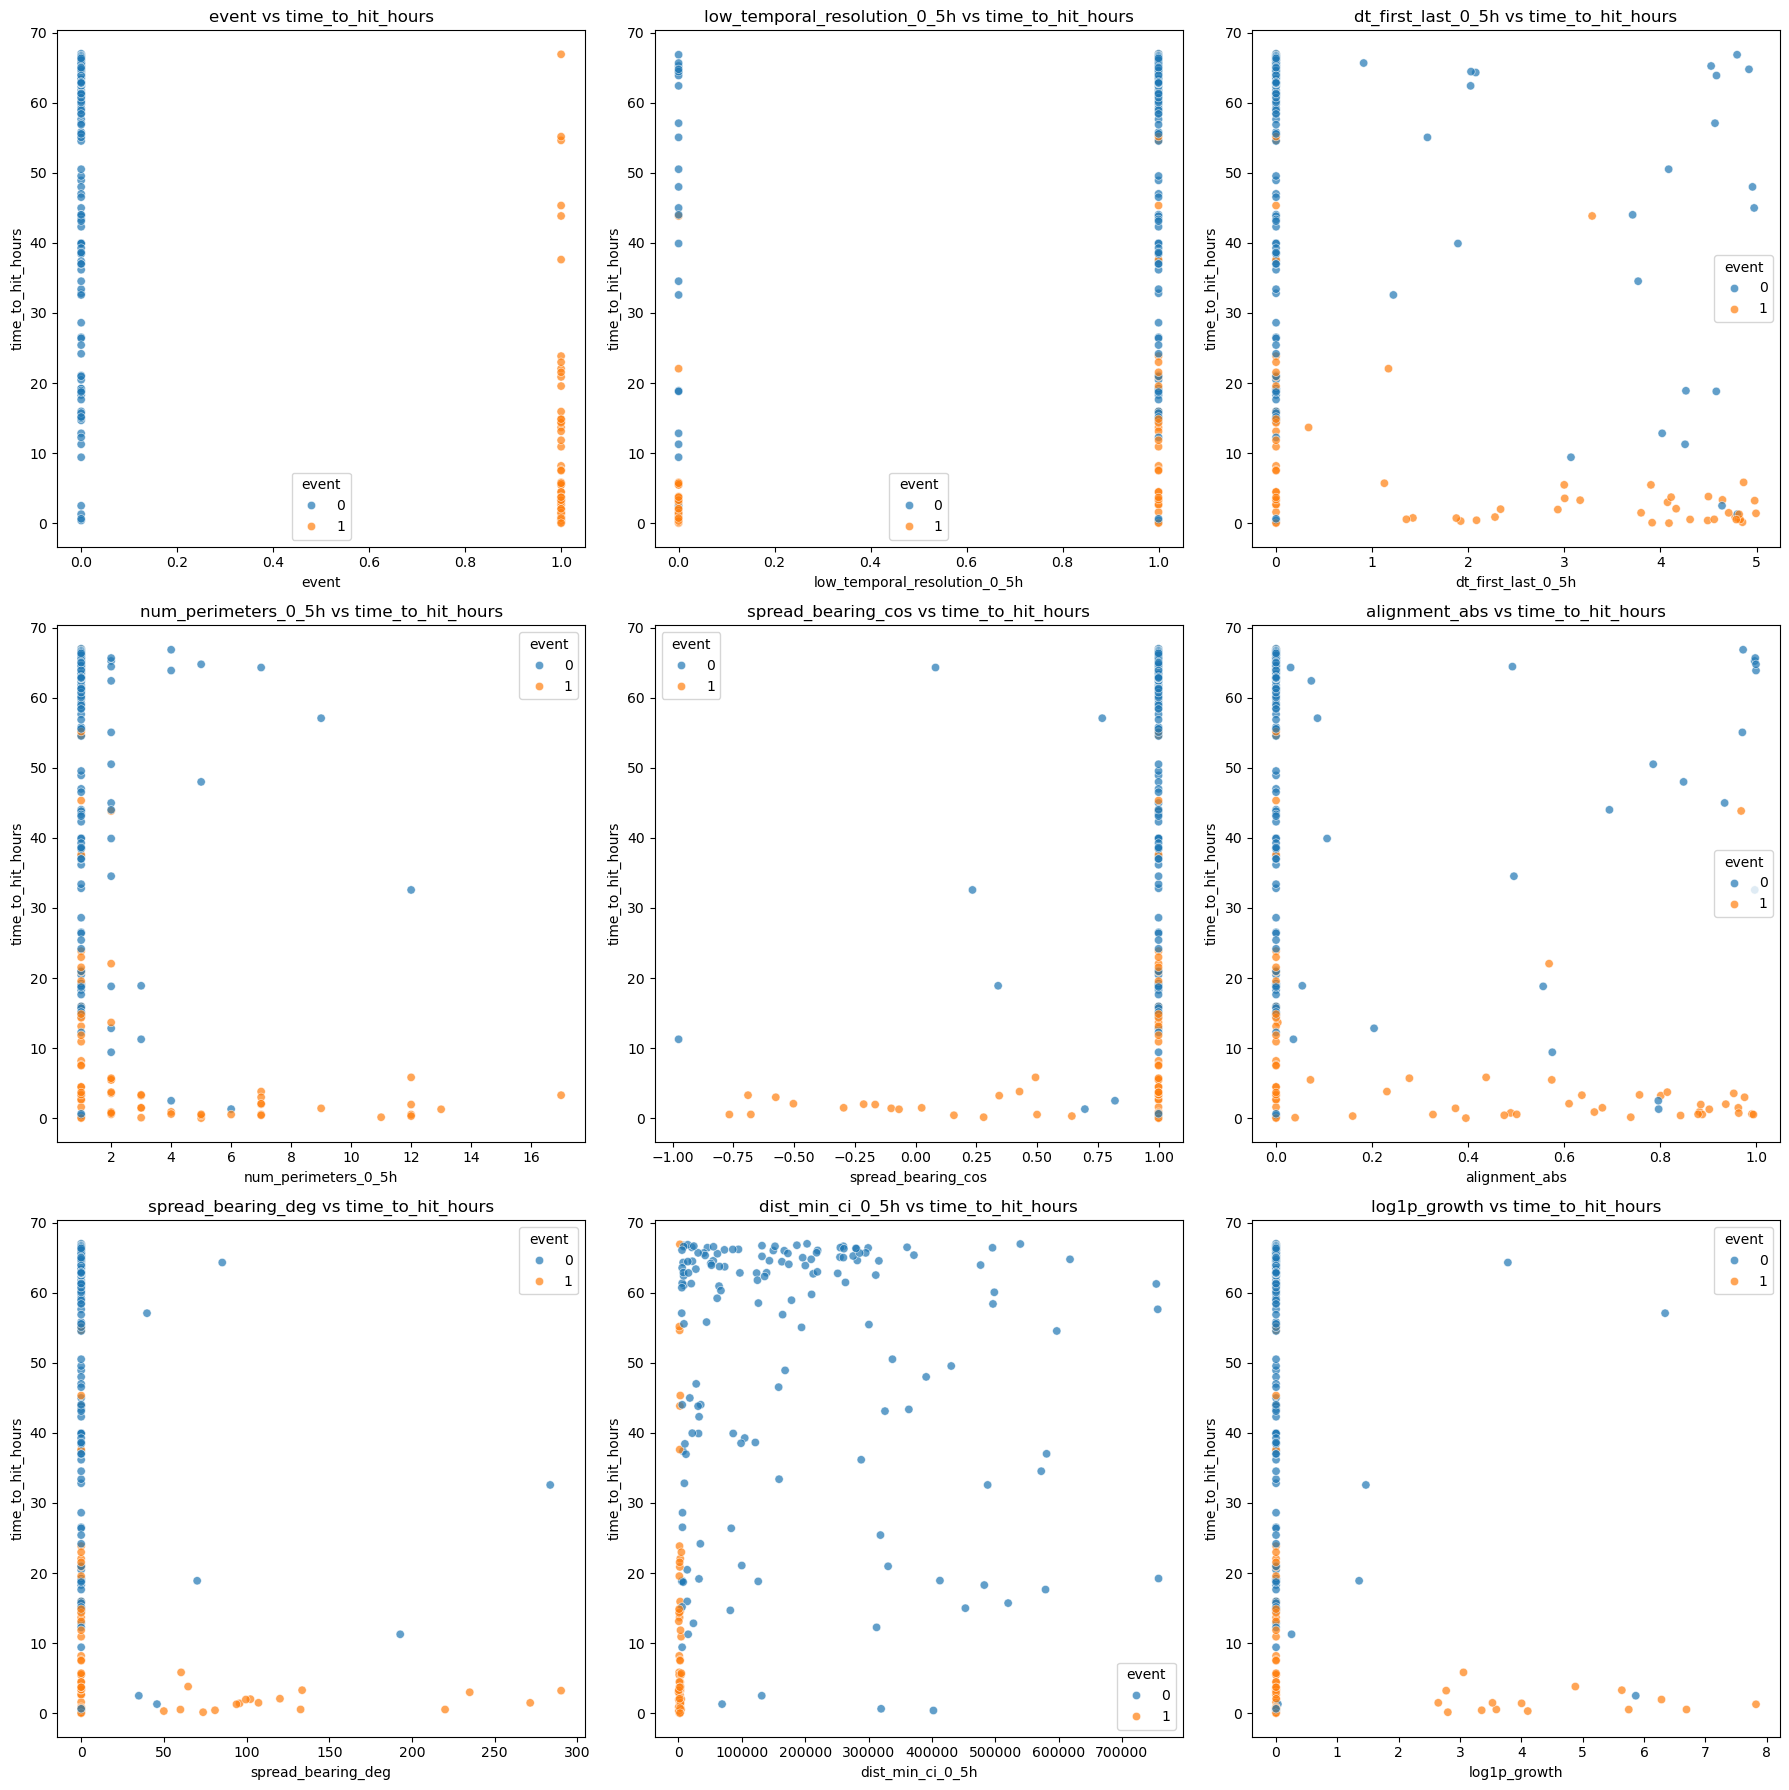

In [46]:
# مرتبطة بالهدف features (9)يأخذ أهم
top_time_features = corr_time.head(9).index.tolist()

plt.figure(figsize=(18, 18))
for i, col in enumerate(top_time_features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(data=train, x=col, y=TARGET_TIME, hue=TARGET_EVENT, alpha=0.7)
    plt.title(f"{col} vs {TARGET_TIME}")
plt.tight_layout()
plt.show()

# Boxplots feature by event


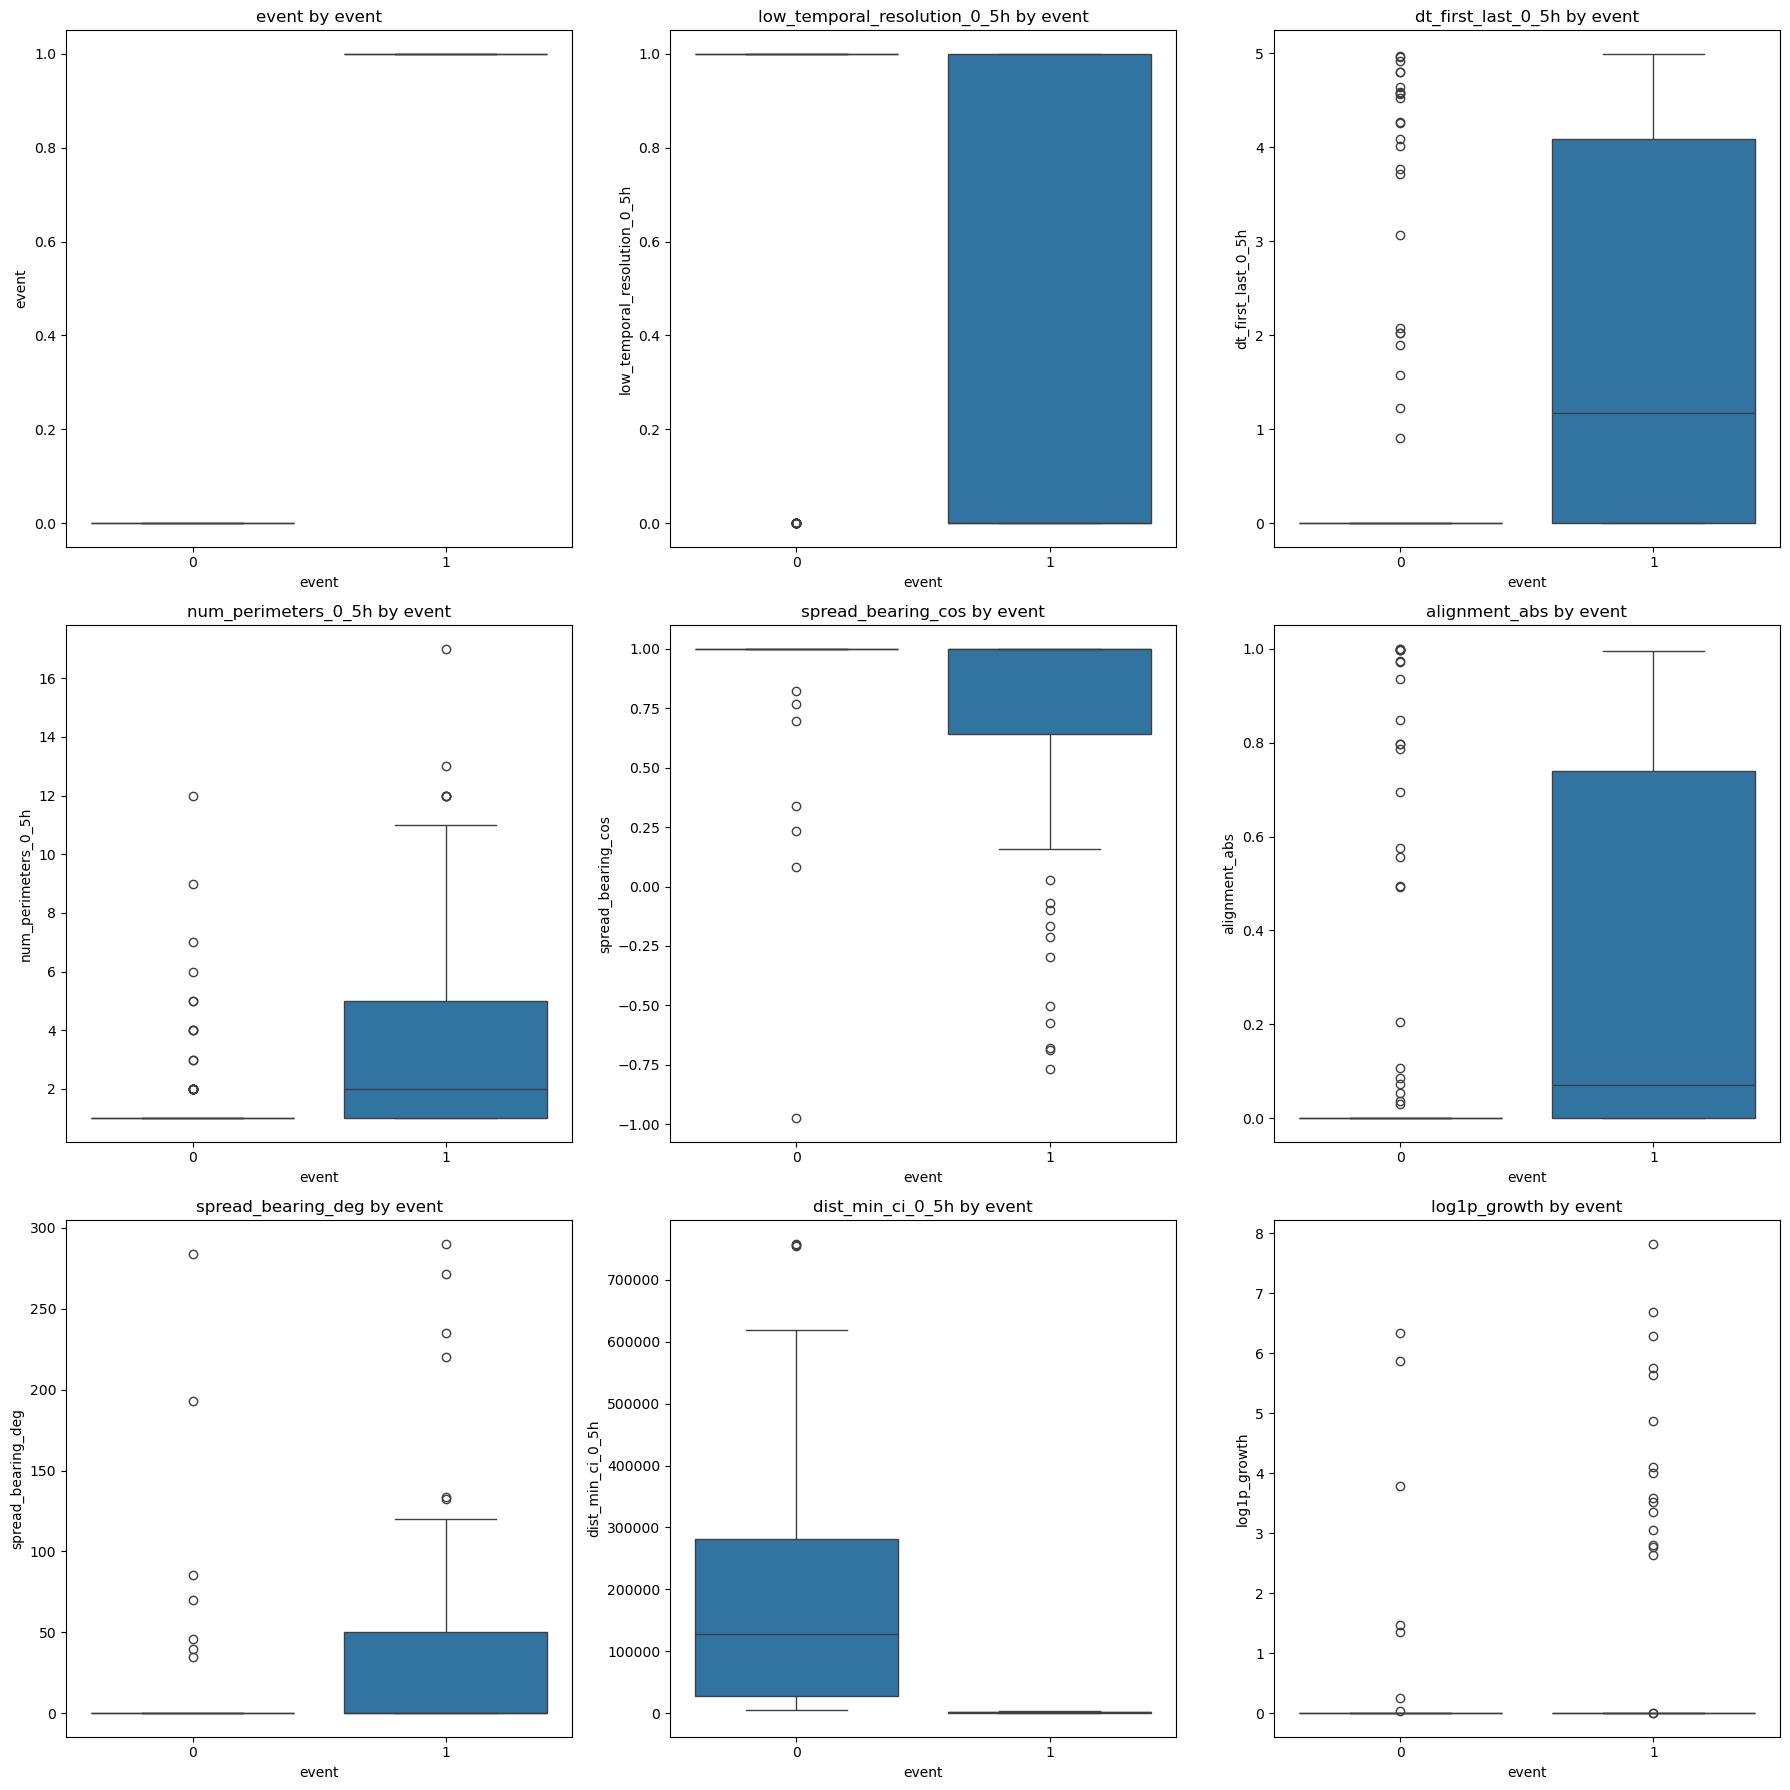

In [47]:
plt.figure(figsize=(18, 18))
for i, col in enumerate(top_time_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=train, x=TARGET_EVENT, y=col)
    plt.title(f"{col} by {TARGET_EVENT}")
plt.tight_layout()
plt.show()

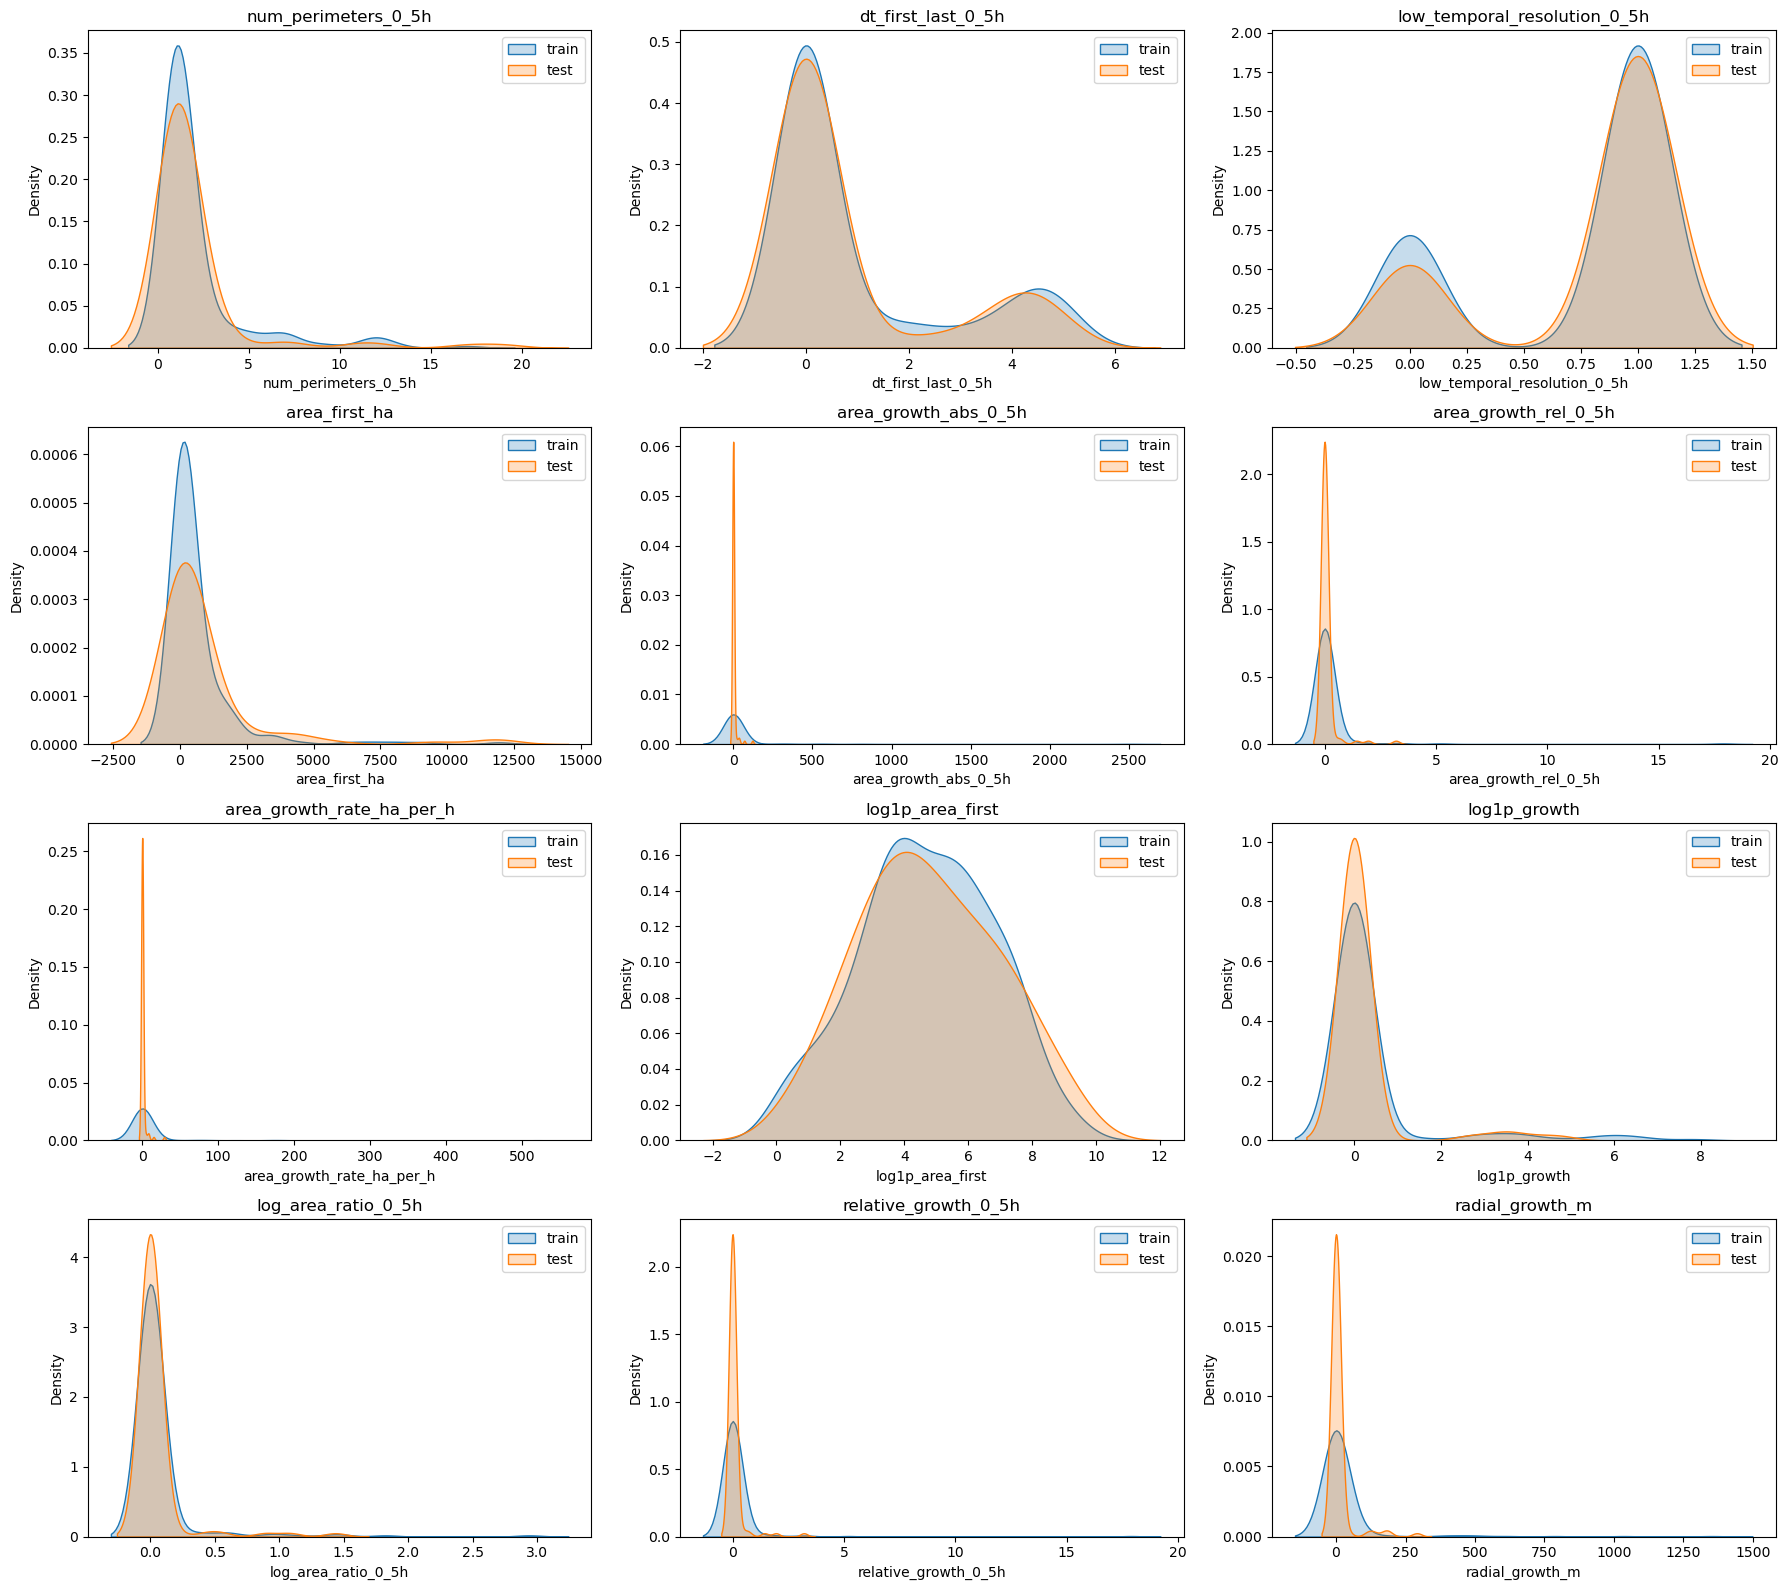

In [48]:
 #test و train هاي دالة تقارن توزيع العمود نفسه بين
def compare_train_test_distributions(train_df, test_df, cols, n_cols=3):
    n = len(cols)
    n_rows = int(np.ceil(n / n_cols))
    plt.figure(figsize=(n_cols * 6, n_rows * 4))

  #test و واحد لل  train يرسم منحنيين واحد لل
    for i, col in enumerate(cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.kdeplot(train_df[col], label="train", fill=True)
        sns.kdeplot(test_df[col], label="test", fill=True)
        plt.title(col)
        plt.legend()

    plt.tight_layout()
    plt.show()

compare_train_test_distributions(train, test, numeric_cols[:12], n_cols=3)

In [49]:
# Summary stats comparison
# test و train يبني جدول مقارنة إحصائي بين
train_stats = train[numeric_cols].describe().T.add_prefix("train_")
test_stats = test[numeric_cols].describe().T.add_prefix("test_")

comparison_stats = train_stats.merge(test_stats, left_index=True, right_index=True)
display(comparison_stats.head(20))

,train_count,train_mean,train_std,train_min,train_25%,train_50%,train_75%,train_max,test_count,test_mean,test_std,test_min,test_25%,test_50%,test_75%,test_max
num_perimeters_0_5h,221.0,2.063348,2.578859,1.000000e+00,1.000000,1.000000,2.000000,17.000000,95.0,1.926316,2.965196,1.000000,1.000000,1.000000,1.000000,19.000000
dt_first_last_0_5h,221.0,0.979869,1.738052,0.000000e+00,0.000000,0.000000,1.356107,4.994457,95.0,0.832315,1.650526,0.000000,0.000000,0.000000,0.000000,4.884515
low_temporal_resolution_0_5h,221.0,0.728507,0.445739,0.000000e+00,0.000000,1.000000,1.000000,1.000000,95.0,0.778947,0.417157,0.000000,1.000000,1.000000,1.000000,1.000000
area_first_ha,221.0,619.131641,1447.723668,3.752484e-02,25.219058,110.149250,485.092561,11942.392110,95.0,891.299795,2144.075209,0.396510,25.561885,84.586007,632.579516,11964.104587
area_growth_abs_0_5h,221.0,26.332398,187.437018,-2.160000e-05,0.000000,0.000000,0.000000,2508.041442,95.0,3.127903,15.266385,0.000000,0.000000,0.000000,0.000000,121.449247
area_growth_rel_0_5h,221.0,0.178909,1.302001,-1.440000e-07,0.000000,0.000000,0.000000,17.889695,95.0,0.084938,0.416592,0.000000,0.000000,0.000000,0.000000,3.202315
area_growth_rate_ha_per_h,221.0,6.167128,40.467370,-5.290000e-06,0.000000,0.000000,0.000000,520.443033,95.0,0.726143,3.551966,0.000000,0.000000,0.000000,0.000000,29.006158
log1p_area_first,221.0,4.683276,2.083529,3.683791e-02,3.266487,4.710874,6.186399,9.387933,95.0,4.766501,2.184843,0.333976,3.278582,4.449522,6.438102,9.389750
log1p_growth,221.0,0.389346,1.340348,0.000000e+00,0.000000,0.000000,0.000000,7.827656,95.0,0.234737,0.913950,0.000000,0.000000,0.000000,0.000000,4.807697
log_area_ratio_0_5h,221.0,0.065434,0.300321,-1.440000e-07,0.000000,0.000000,0.000000,2.938617,95.0,0.048183,0.214588,0.000000,0.000000,0.000000,0.000000,1.435635


In [ ]:
'''
مع feature يبني جدول يلخص كل
ارتباطها بالوقت
ارتباطها بالحدث

'''
importance_table = pd.DataFrame({
    "feature": corr_time.index,
    "corr_with_time_to_hit": corr_time.values,
    "corr_with_event": corr_event.reindex(corr_time.index).values
}).sort_values("corr_with_time_to_hit", key=np.abs, ascending=False)

display(importance_table.head(20))

# Group-based EDA from metadata categories

In [50]:
#يبني قاموس يربط اسم العمود بفئته
category_map = meta.set_index("column")["category"].to_dict()

#category حسب  feature عشان نصنف كل
'''
بدل ما نحكي "هاد العمود قوي"، نصير نحكي
أقوى distance أعمدة
أهم growth أو
أضعف temporal features أو

'''
feature_category_df = pd.DataFrame({
    "feature": feature_cols,
    "category": [category_map.get(c, "unknown") for c in feature_cols]
})

display(feature_category_df.sort_values(["category", "feature"]))

,feature,category
13,centroid_displacement_m,centroid_kinematics
14,centroid_speed_m_per_h,centroid_kinematics
17,spread_bearing_cos,centroid_kinematics
15,spread_bearing_deg,centroid_kinematics
16,spread_bearing_sin,centroid_kinematics
28,alignment_abs,directionality
27,alignment_cos,directionality
30,along_track_speed,directionality
29,cross_track_component,directionality
23,closing_speed_abs_m_per_h,distance


In [51]:
# correlations حسب category
cat_corr_rows = []
for col in feature_cols:
    if col in train.columns and pd.api.types.is_numeric_dtype(train[col]):
        cat_corr_rows.append({
            "feature": col,
            "category": category_map.get(col, "unknown"),
            "corr_with_time": train[[col, TARGET_TIME]].corr().iloc[0, 1],
            "corr_with_event": train[[col, TARGET_EVENT]].corr().iloc[0, 1]
        })

cat_corr_df = pd.DataFrame(cat_corr_rows)
display(cat_corr_df.sort_values("corr_with_time", key=np.abs, ascending=False).head(25))

,feature,category,corr_with_time,corr_with_event
2,low_temporal_resolution_0_5h,temporal_coverage,0.442236,-0.379117
1,dt_first_last_0_5h,temporal_coverage,-0.434699,0.352954
0,num_perimeters_0_5h,temporal_coverage,-0.392040,0.370501
17,spread_bearing_cos,centroid_kinematics,0.370451,-0.323189
28,alignment_abs,directionality,-0.366923,0.349115
15,spread_bearing_deg,centroid_kinematics,-0.335598,0.281012
18,dist_min_ci_0_5h,distance,0.324876,-0.481379
8,log1p_growth,growth,-0.317451,0.292688
26,dist_fit_r2_0_5h,distance,-0.284143,0.143101
9,log_area_ratio_0_5h,growth,-0.228119,0.229327


In [52]:
#category متوسط قوة الارتباط حسب
category_strength = cat_corr_df.groupby("category")[["corr_with_time", "corr_with_event"]].mean()
display(category_strength.sort_values("corr_with_time", key=np.abs, ascending=False))

,corr_with_time,corr_with_event
category,,
temporal_coverage,-0.128167,0.114779
growth,-0.123443,0.125976
centroid_kinematics,-0.119630,0.112664
directionality,-0.104403,0.104727
temporal_metadata,0.033541,0.007114
distance,-0.017041,-0.015339


# feature skewnessOptional

In [54]:
skew_df = pd.DataFrame({
    "feature": numeric_cols,
    "skewness": train[numeric_cols].skew().values
}).sort_values("skewness", key=np.abs, ascending=False)

display(skew_df.head(20))

,feature,skewness
21,dist_slope_ci_0_5h,-11.980702
5,area_growth_rel_0_5h,11.951708
10,relative_growth_0_5h,11.951708
19,dist_std_ci_0_5h,11.589398
4,area_growth_abs_0_5h,11.231250
20,dist_change_ci_0_5h,-11.187420
24,projected_advance_m,11.187420
23,closing_speed_abs_m_per_h,11.152232
22,closing_speed_m_per_h,10.994165
6,area_growth_rate_ha_per_h,10.281604


In [56]:
print("===== AUTO EDA NOTES =====")

print(f"- Train rows: {train.shape[0]}, Test rows: {test.shape[0]}")
print(f"- Number of numeric features: {len(numeric_cols)}")
print(f"- Number of categorical features: {len(categorical_cols)}")
print(f"- Duplicate rows in train: {train.duplicated().sum()}")
print(f"- Duplicate rows in test: {test.duplicated().sum()}")

missing_train_total = train.isna().sum().sum()
missing_test_total = test.isna().sum().sum()
print(f"- Total missing values in train: {missing_train_total}")
print(f"- Total missing values in test: {missing_test_total}")

print("\nTop 10 features correlated with time_to_hit_hours:")
display(corr_time.head(10))

print("\nTop 10 features correlated with event:")
display(corr_event.head(10))

===== AUTO EDA NOTES =====
- Train rows: 221, Test rows: 95
- Number of numeric features: 34
- Number of categorical features: 0
- Duplicate rows in train: 0
- Duplicate rows in test: 0
- Total missing values in train: 0
- Total missing values in test: 0

Top 10 features correlated with time_to_hit_hours:


event                          -0.719485
low_temporal_resolution_0_5h    0.442236
dt_first_last_0_5h             -0.434699
num_perimeters_0_5h            -0.392040
spread_bearing_cos              0.370451
alignment_abs                  -0.366923
spread_bearing_deg             -0.335598
dist_min_ci_0_5h                0.324876
log1p_growth                   -0.317451
dist_fit_r2_0_5h               -0.284143
Name: time_to_hit_hours, dtype: float64


Top 10 features correlated with event:


time_to_hit_hours              -0.719485
dist_min_ci_0_5h               -0.481379
low_temporal_resolution_0_5h   -0.379117
num_perimeters_0_5h             0.370501
dt_first_last_0_5h              0.352954
alignment_abs                   0.349115
spread_bearing_cos             -0.323189
log1p_growth                    0.292688
spread_bearing_deg              0.281012
log_area_ratio_0_5h             0.229327
Name: event, dtype: float64

In [57]:
candidate_features = list(dict.fromkeys(
    corr_time.head(12).index.tolist() + corr_event.head(12).index.tolist()
))

print("Candidate features:")
print(candidate_features)

Candidate features:
['event', 'low_temporal_resolution_0_5h', 'dt_first_last_0_5h', 'num_perimeters_0_5h', 'spread_bearing_cos', 'alignment_abs', 'spread_bearing_deg', 'dist_min_ci_0_5h', 'log1p_growth', 'dist_fit_r2_0_5h', 'log_area_ratio_0_5h', 'radial_growth_rate_m_per_h', 'time_to_hit_hours', 'radial_growth_m']


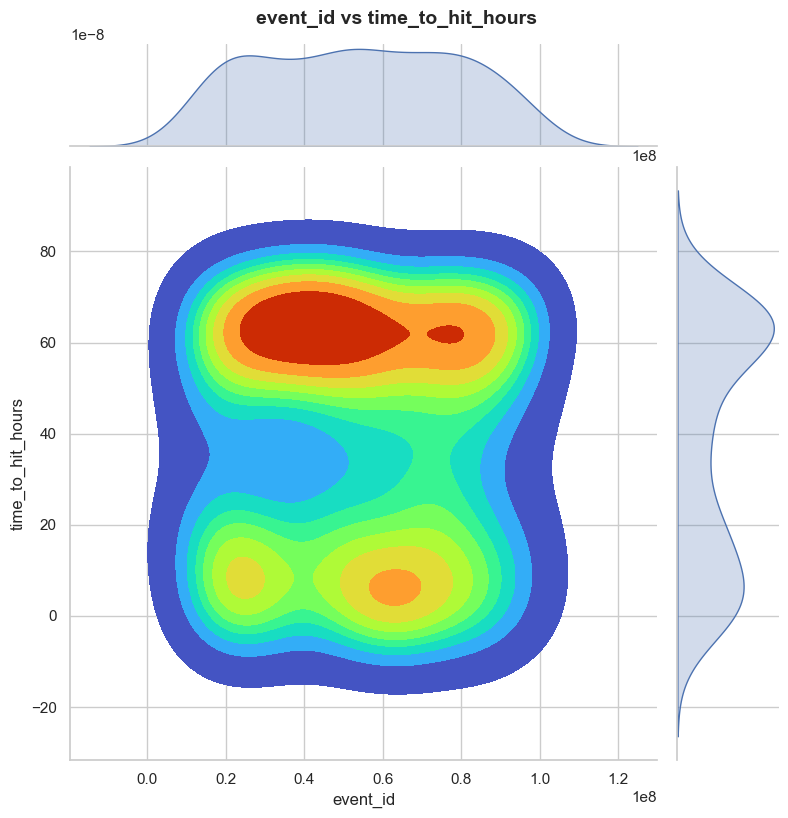

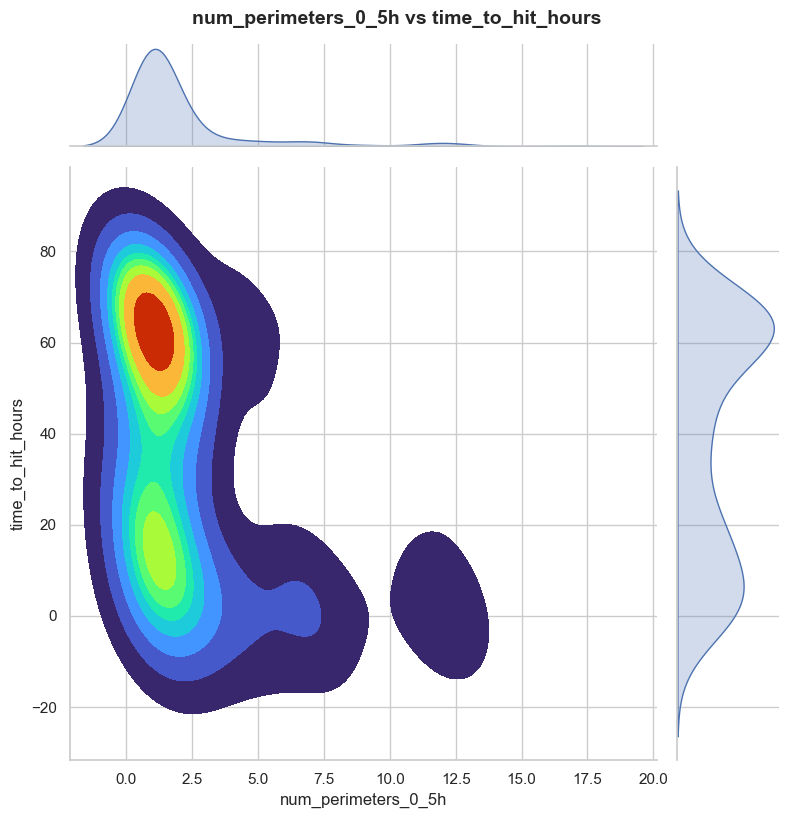

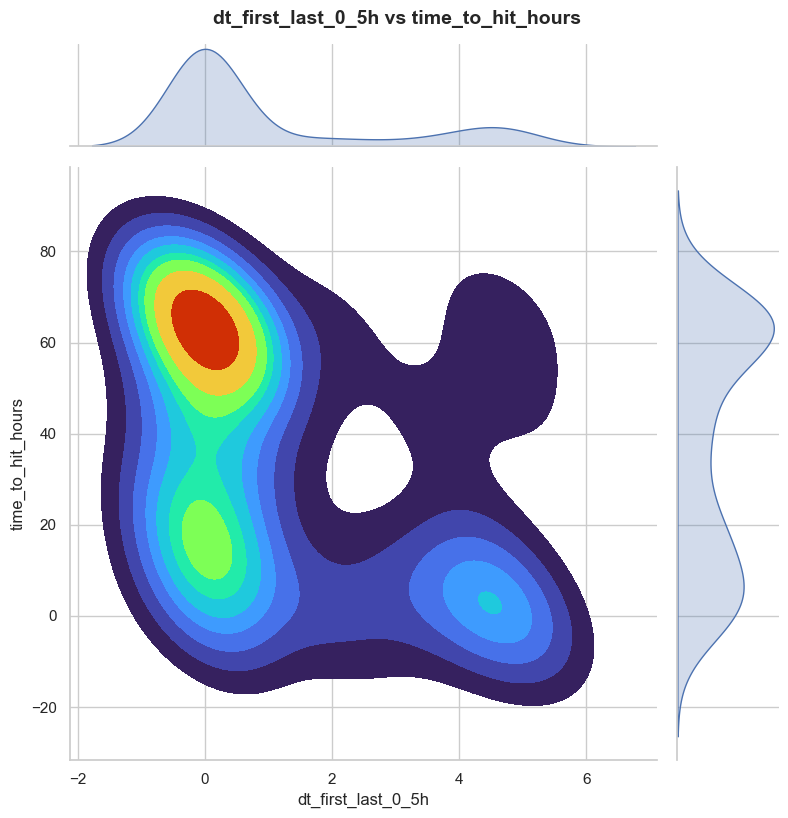

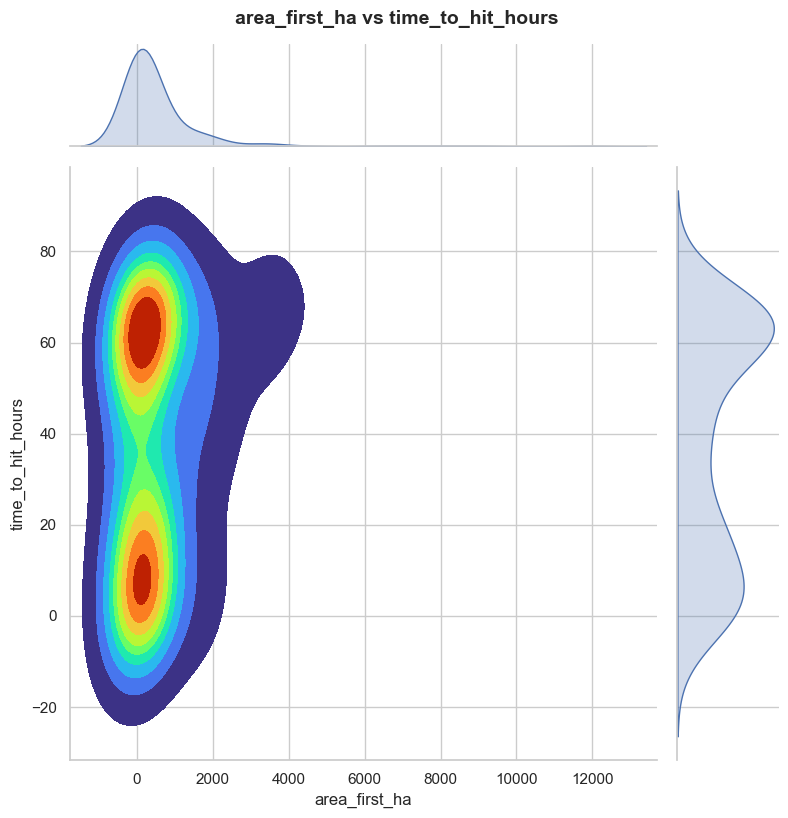

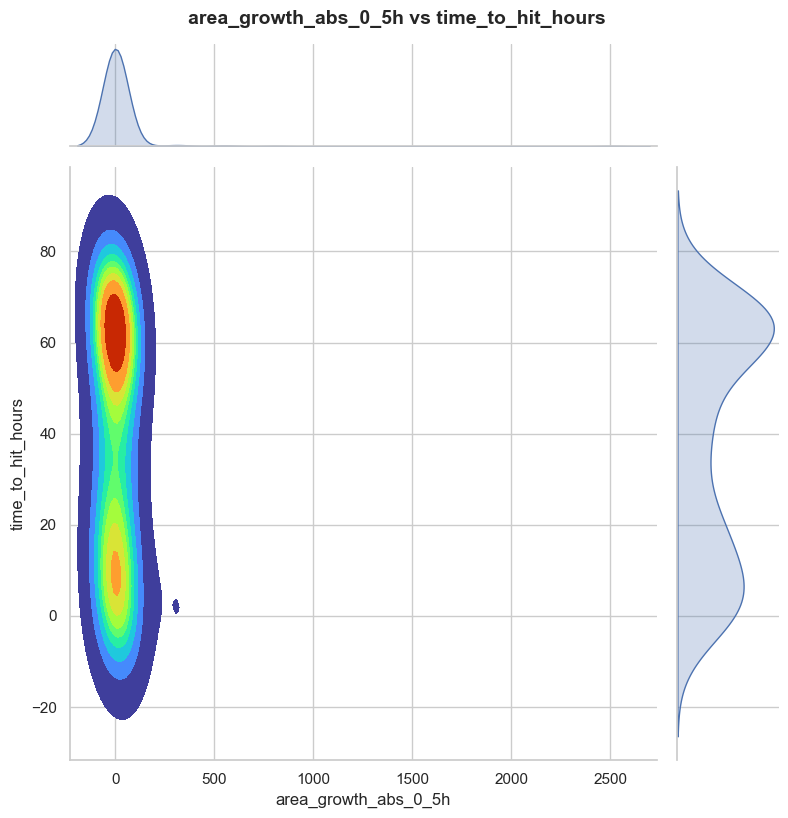

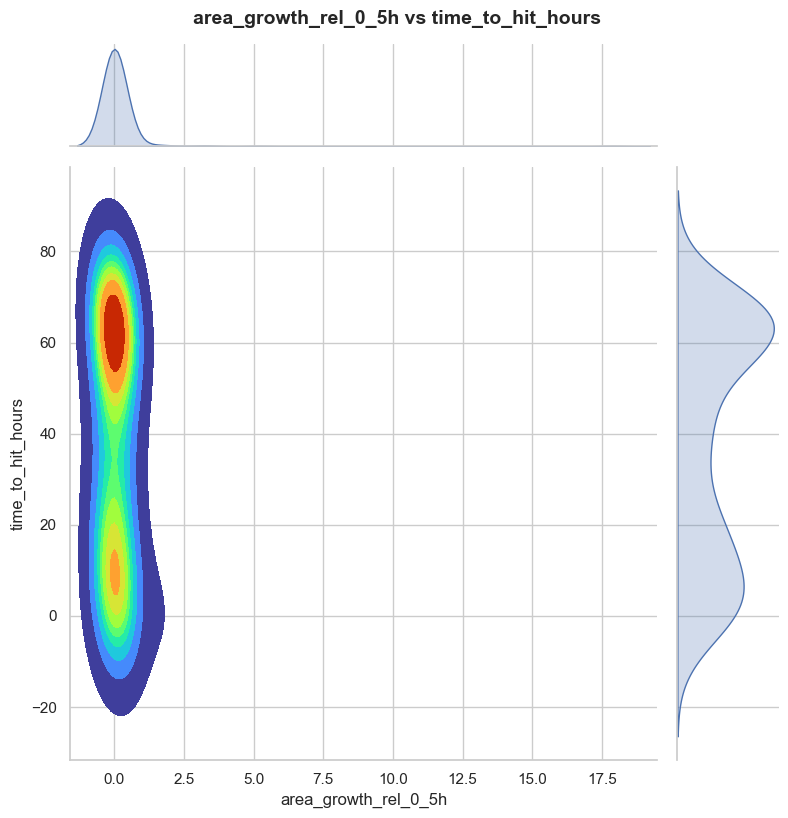

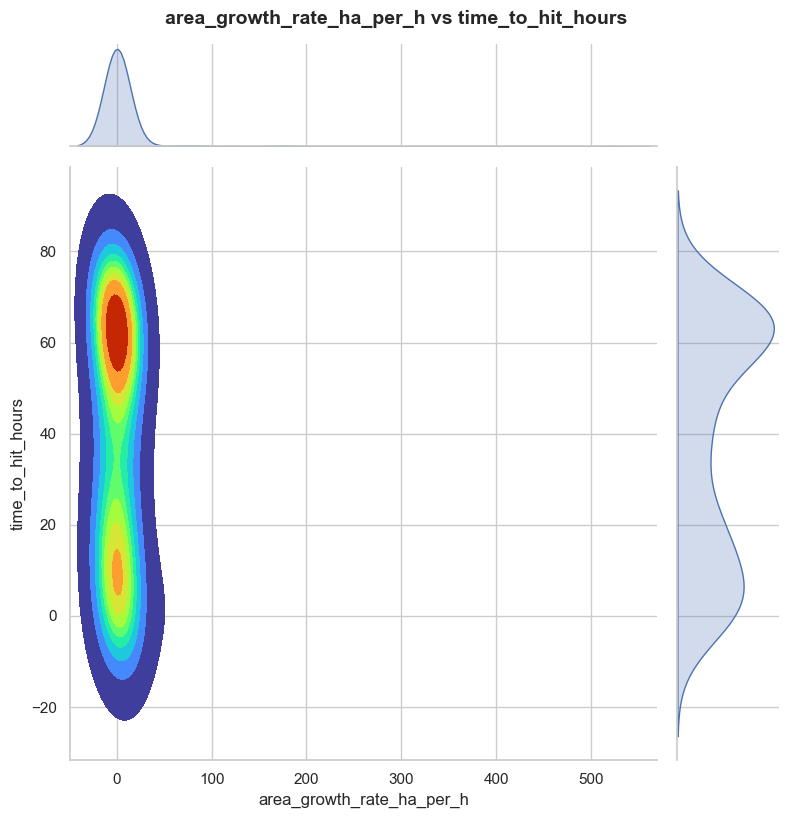

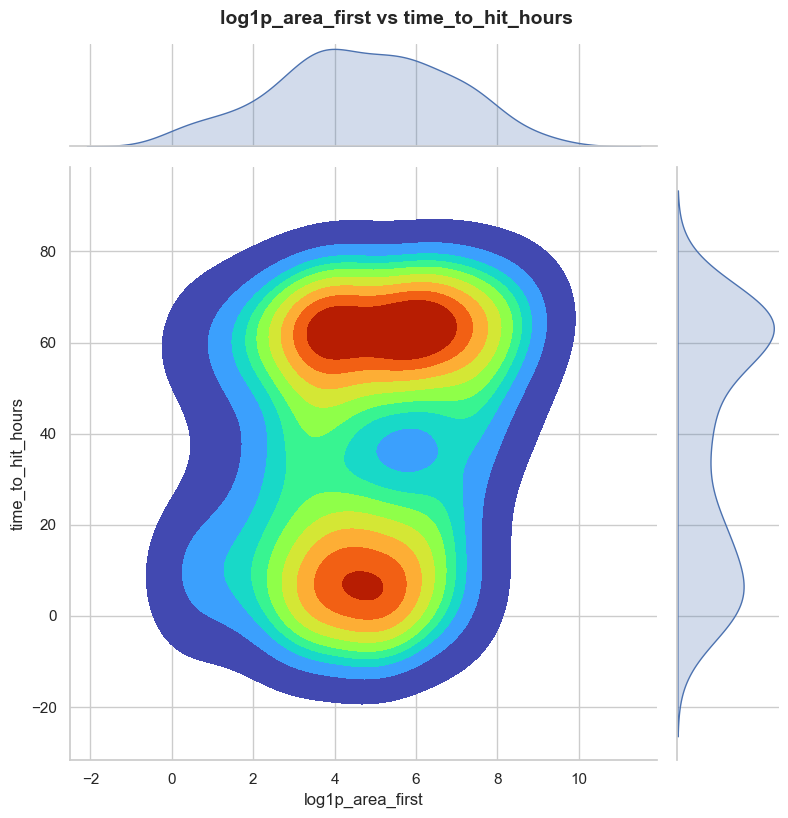

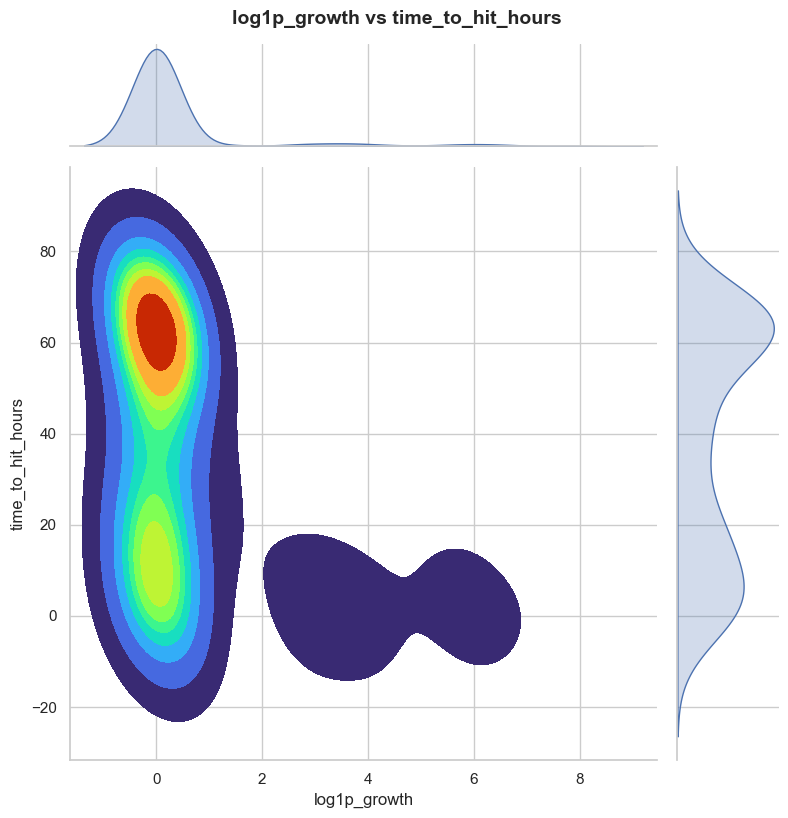

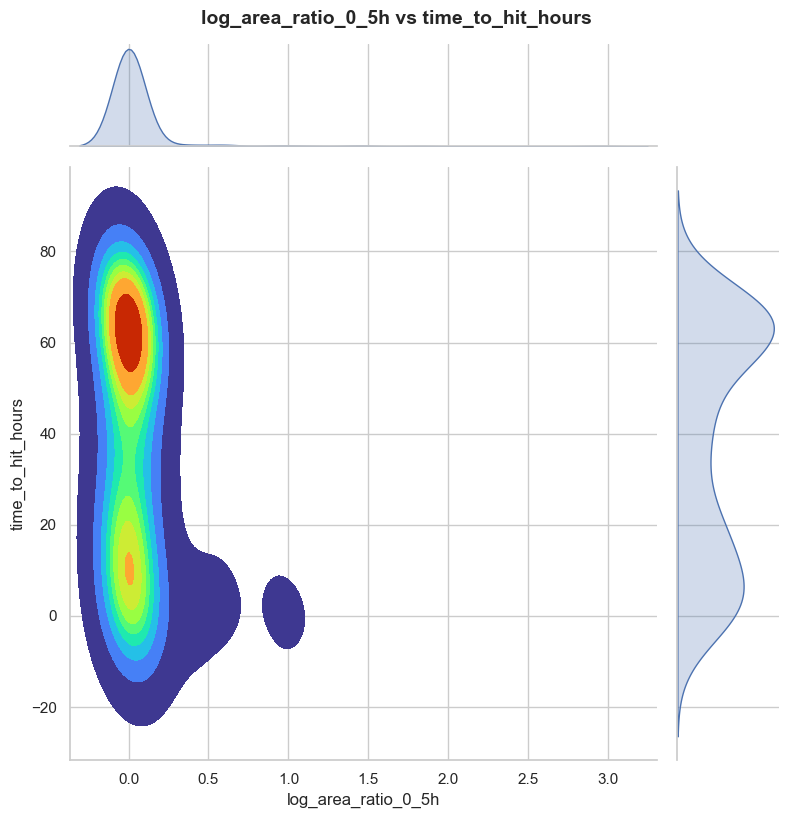

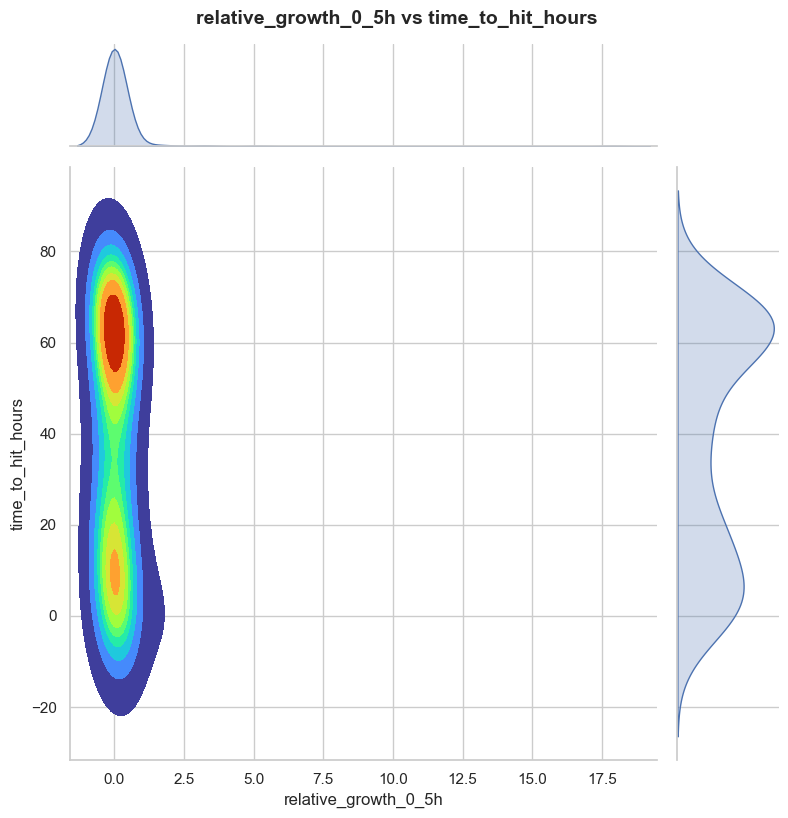

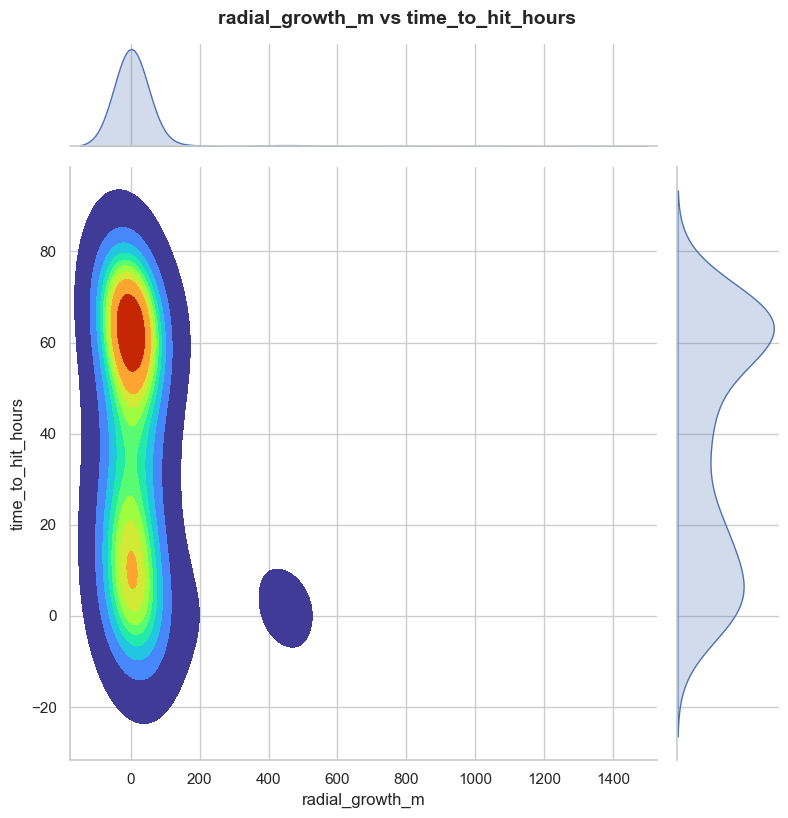

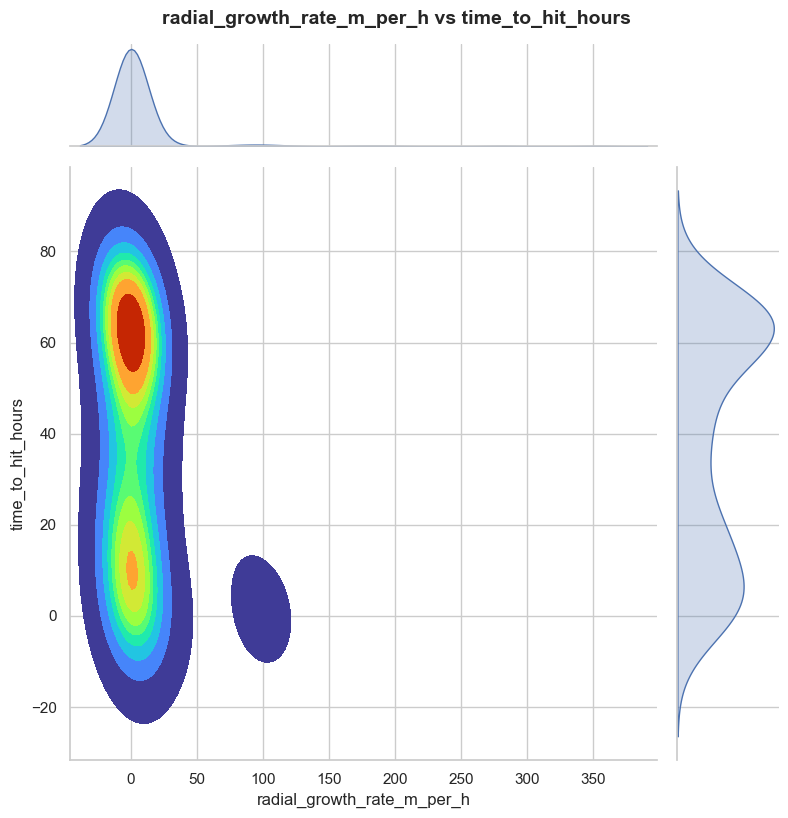

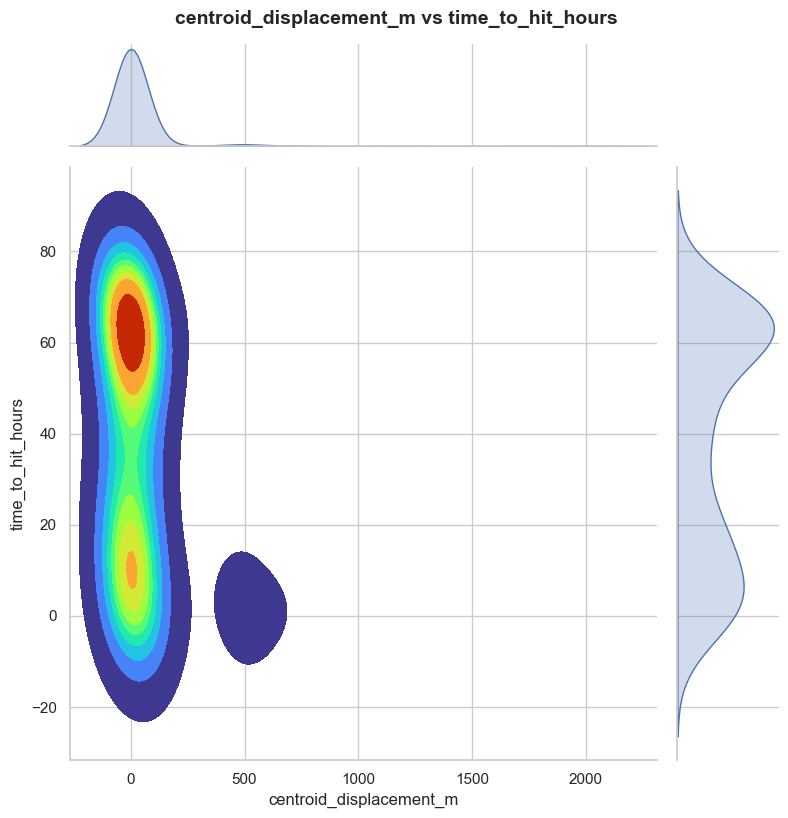

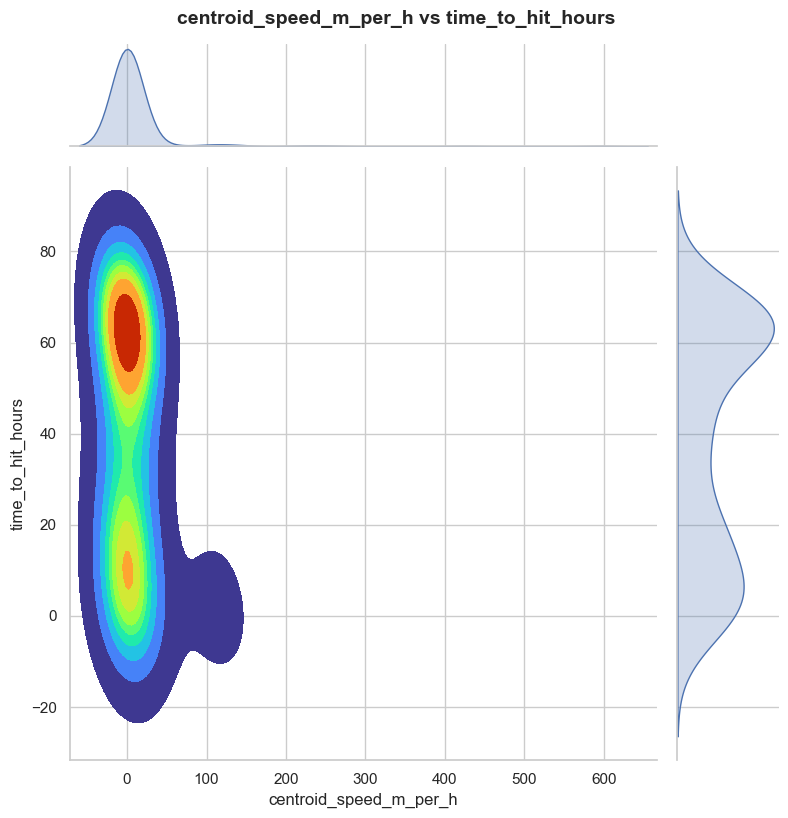

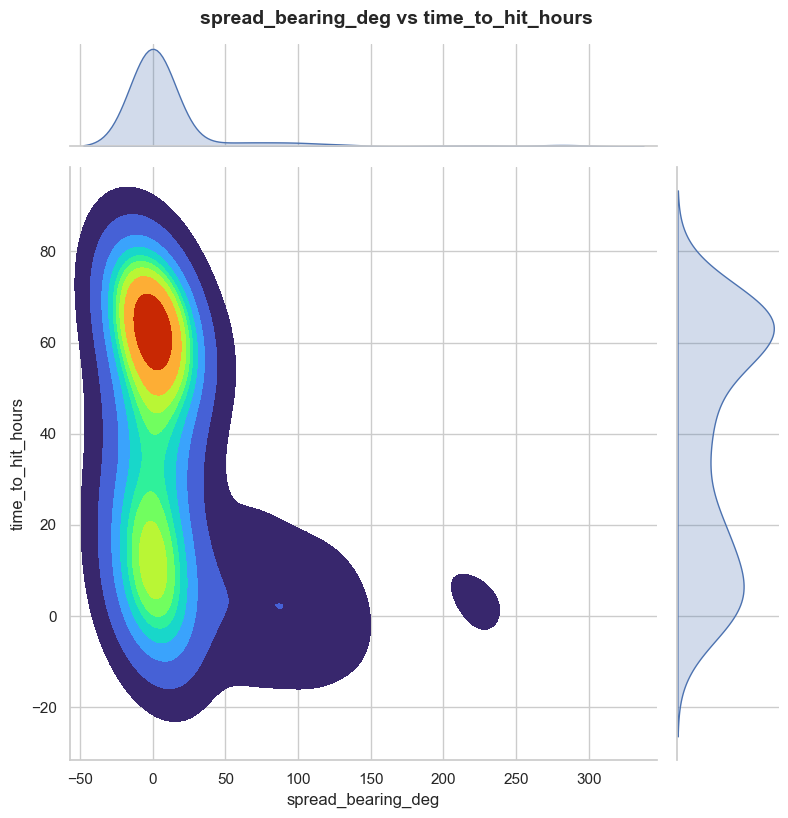

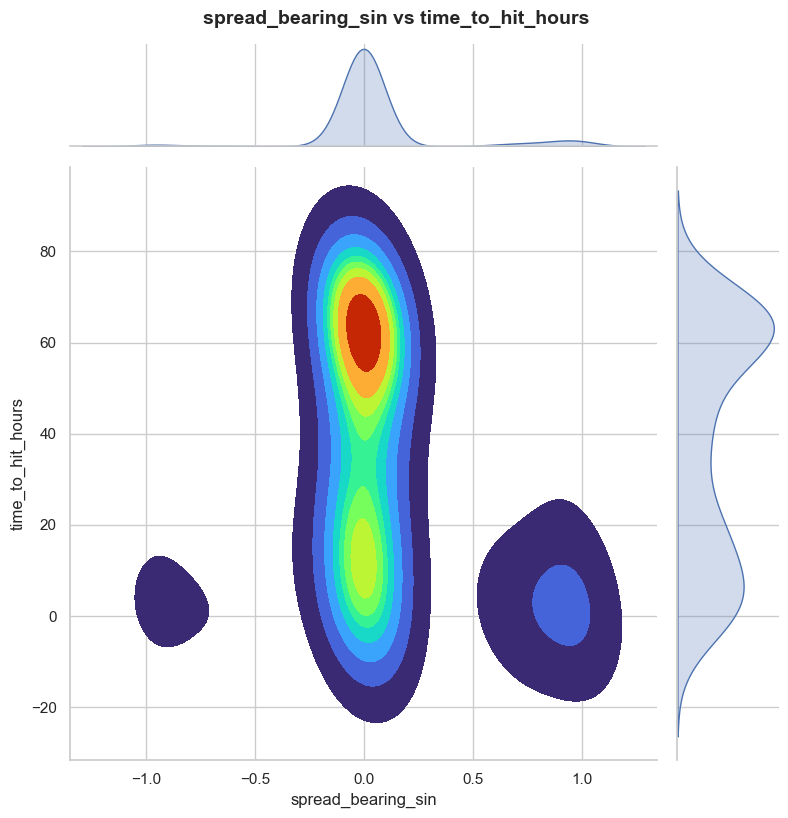

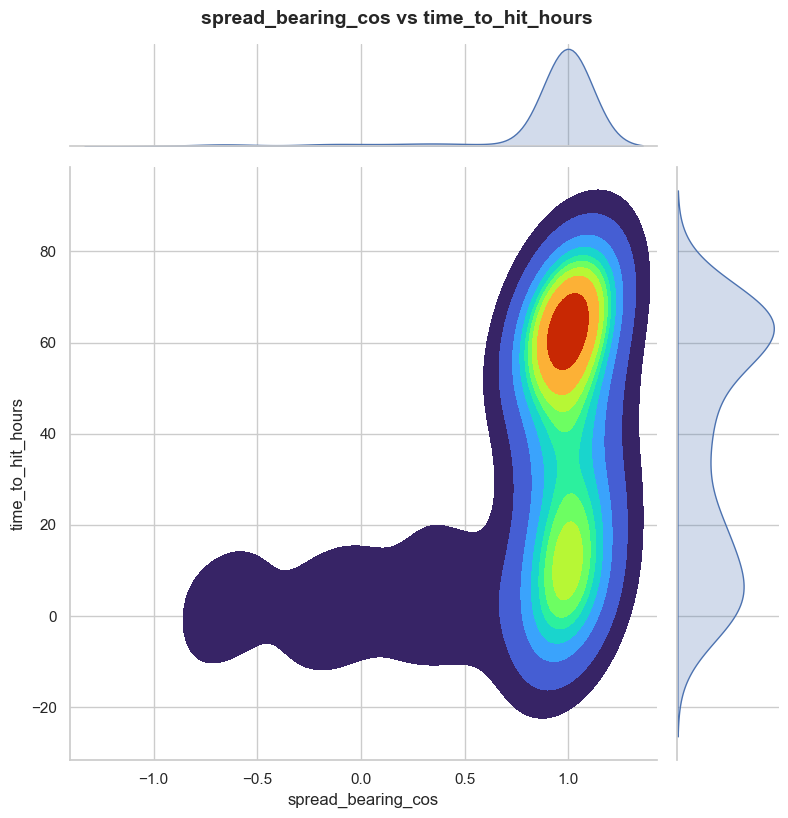

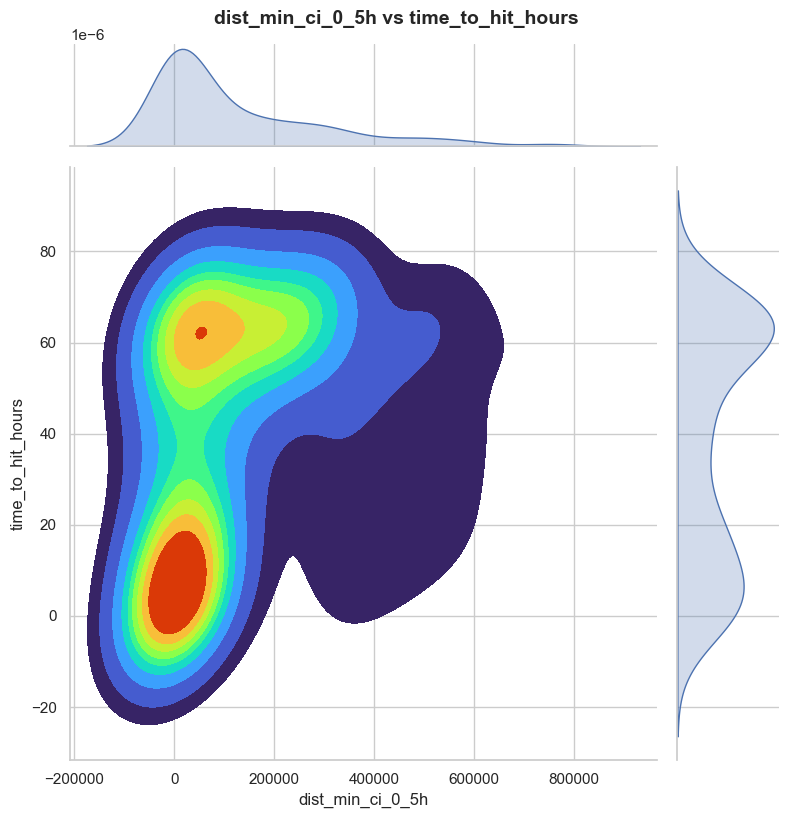

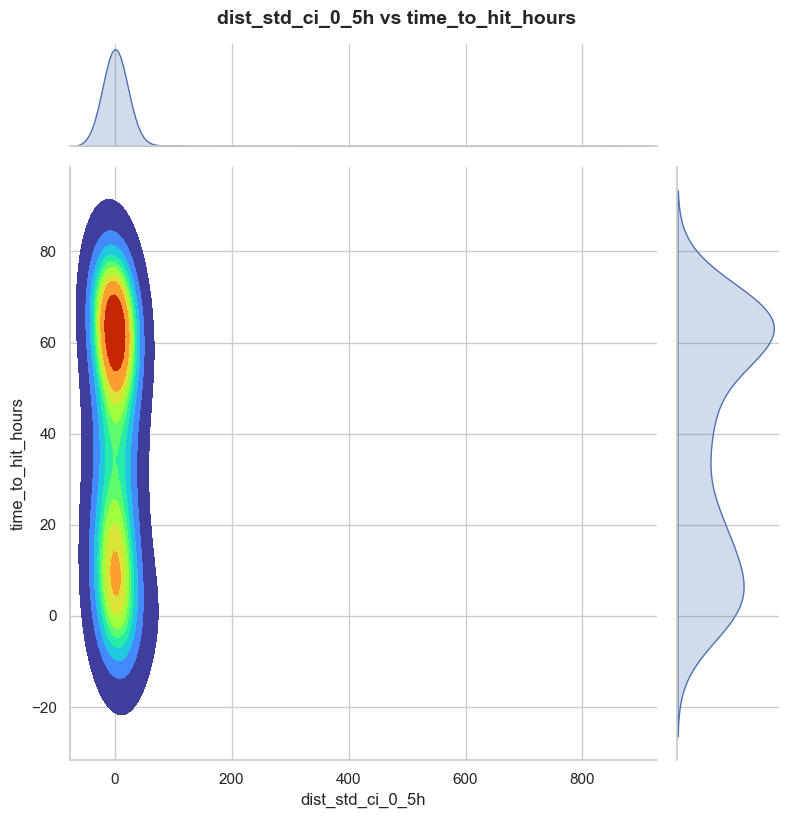

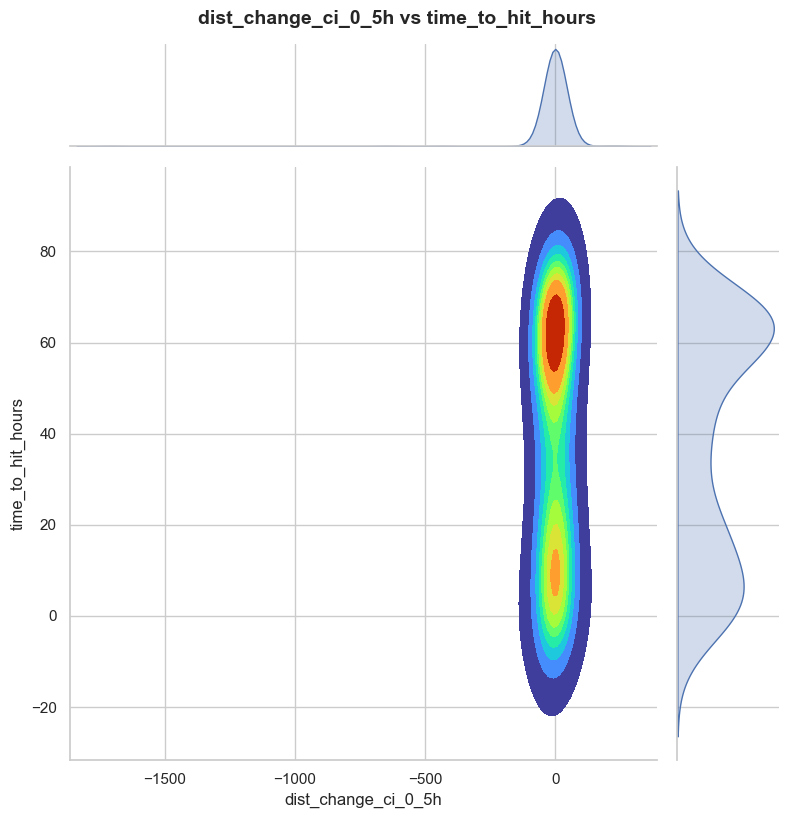

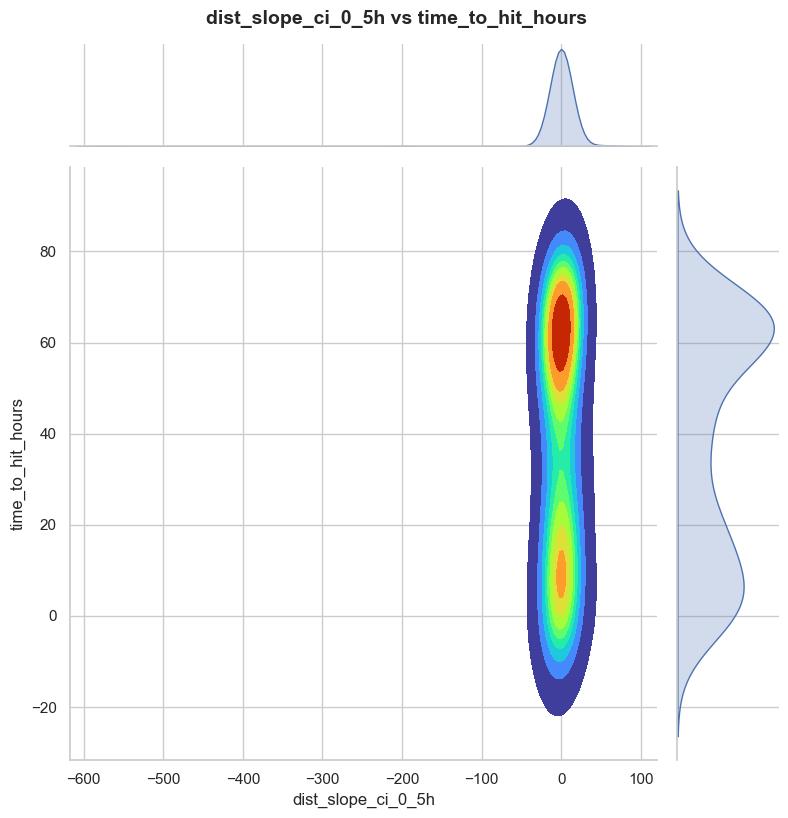

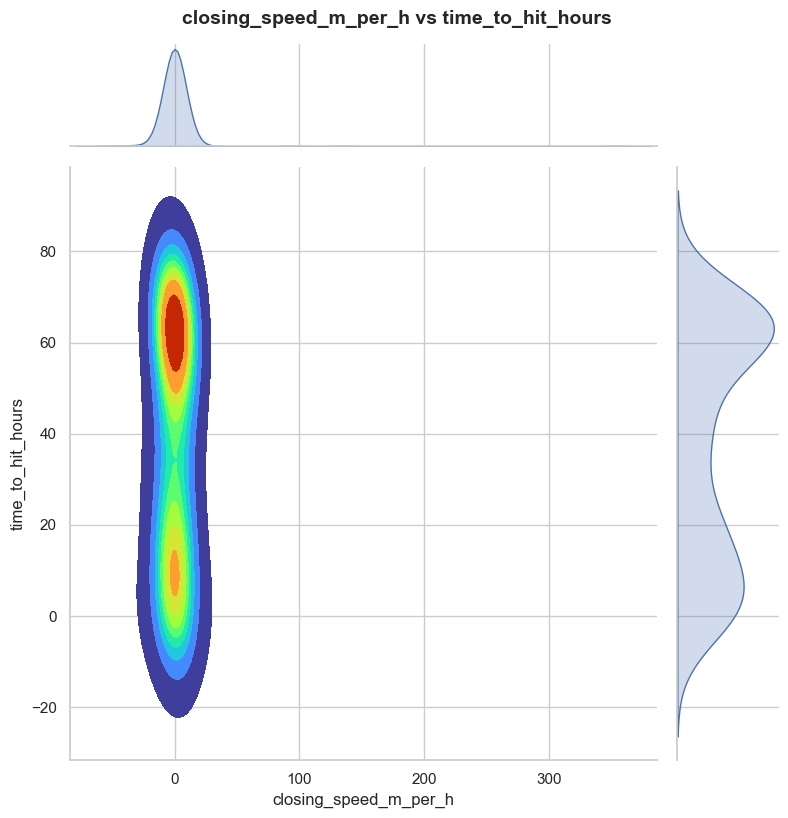

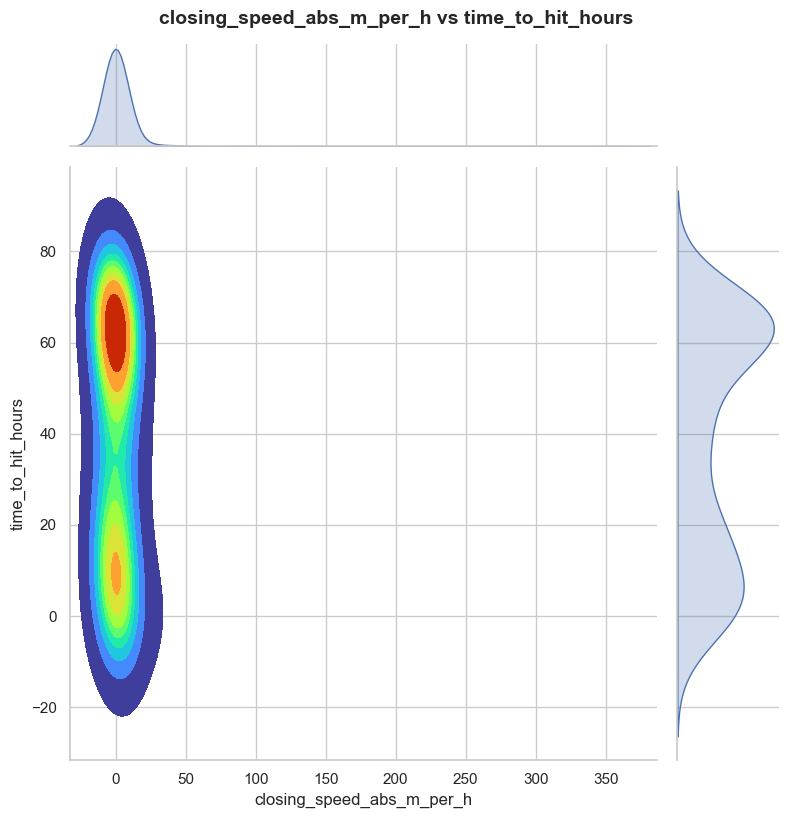

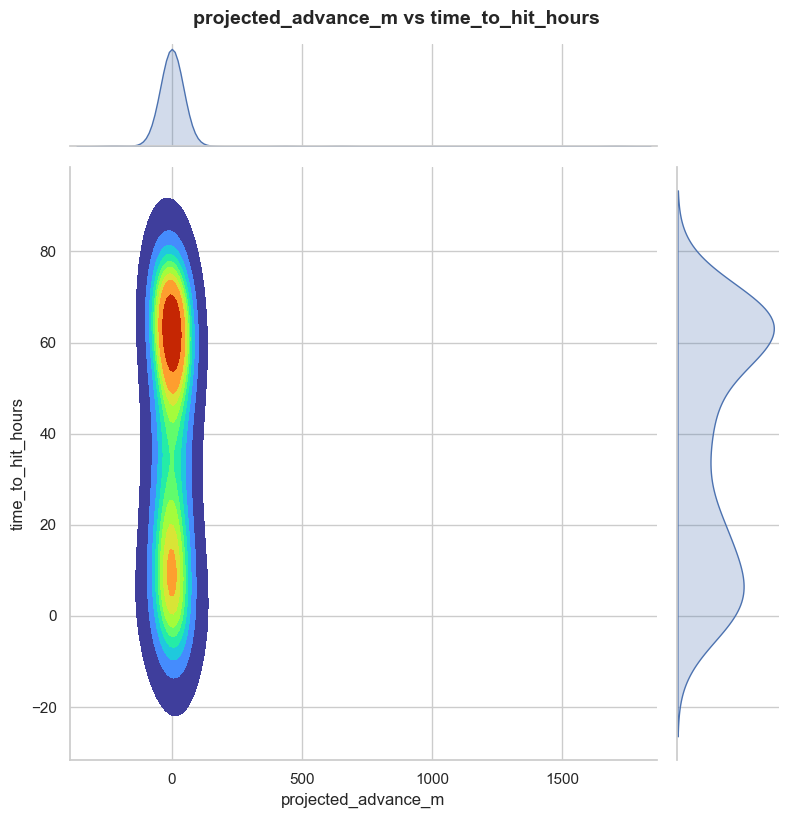

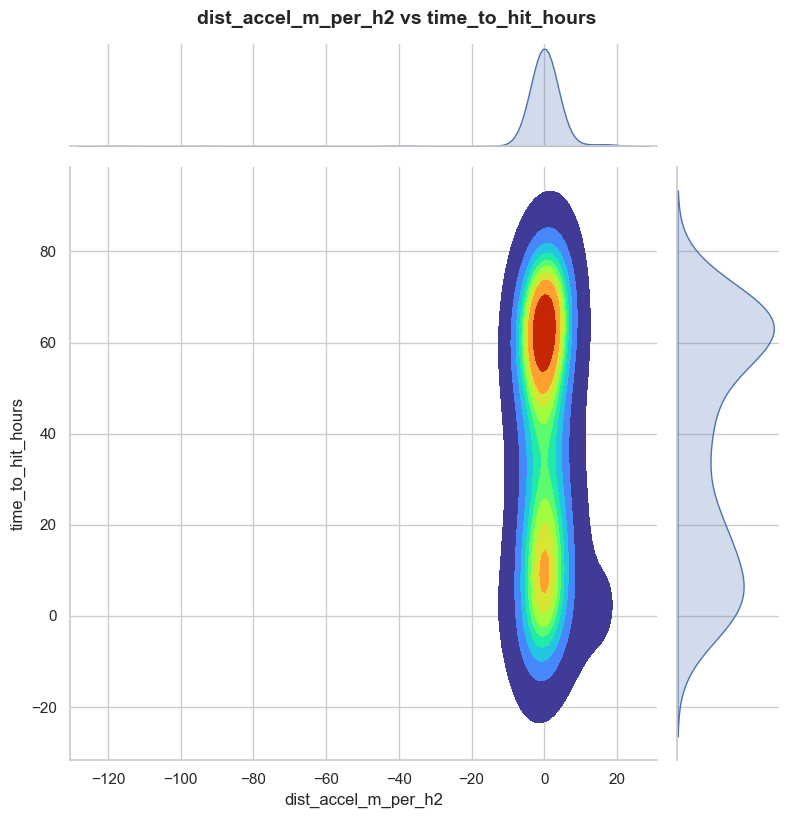

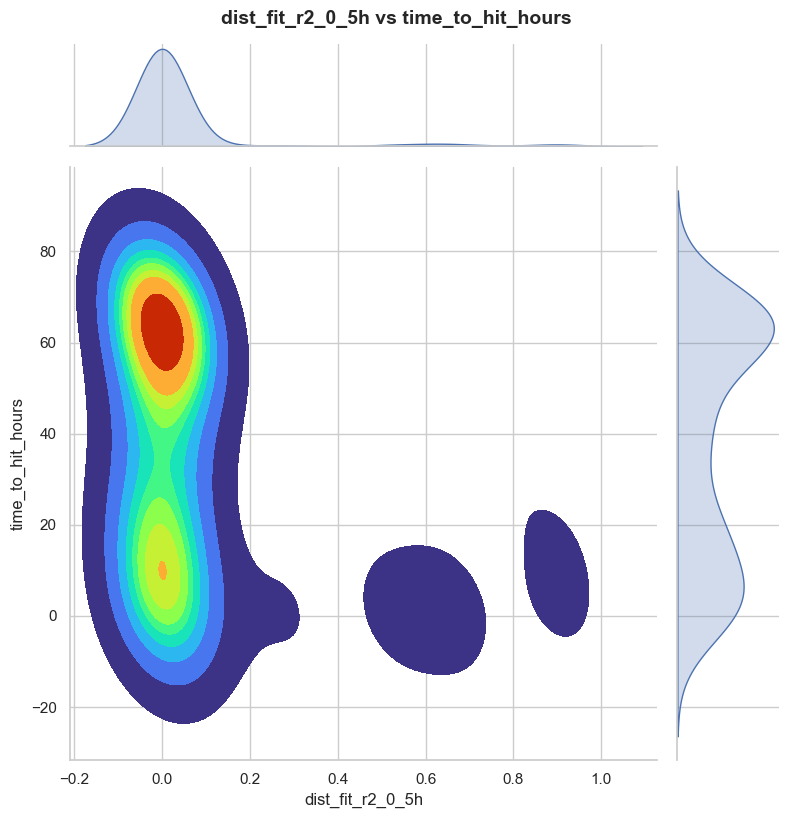

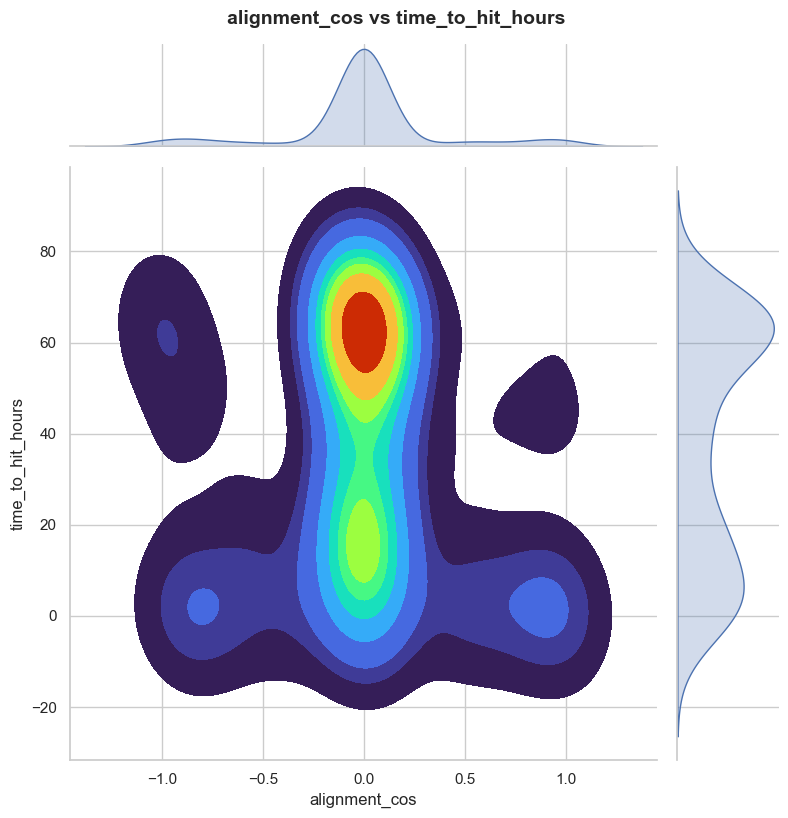

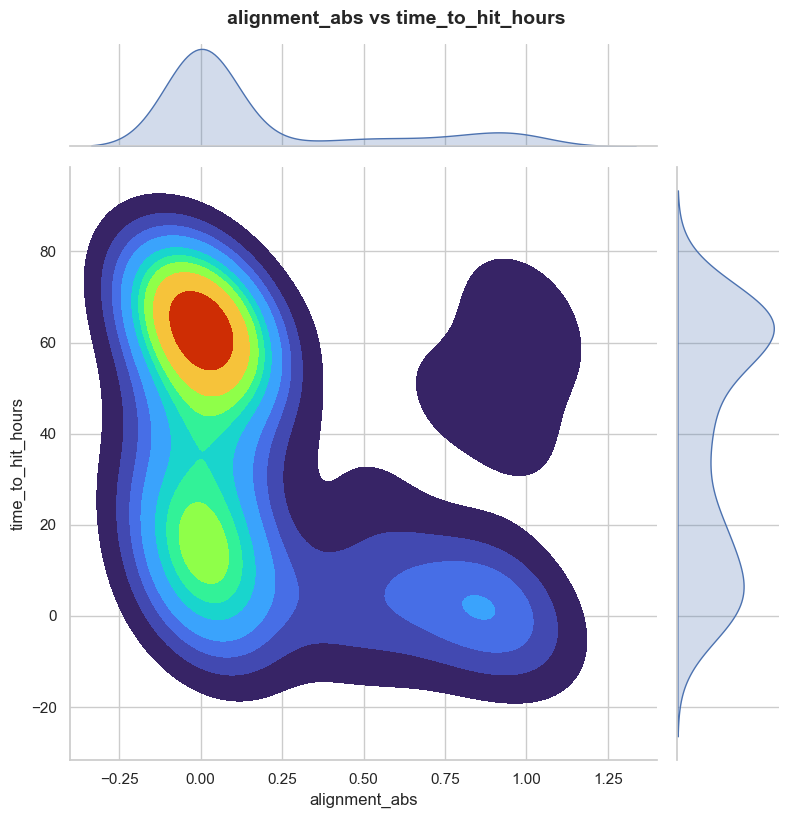

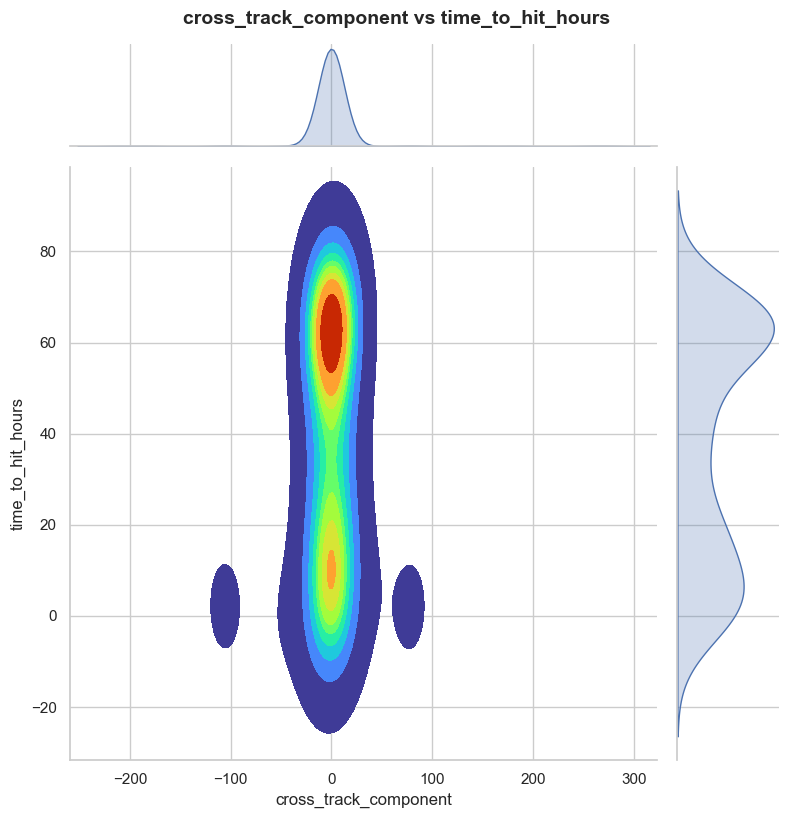

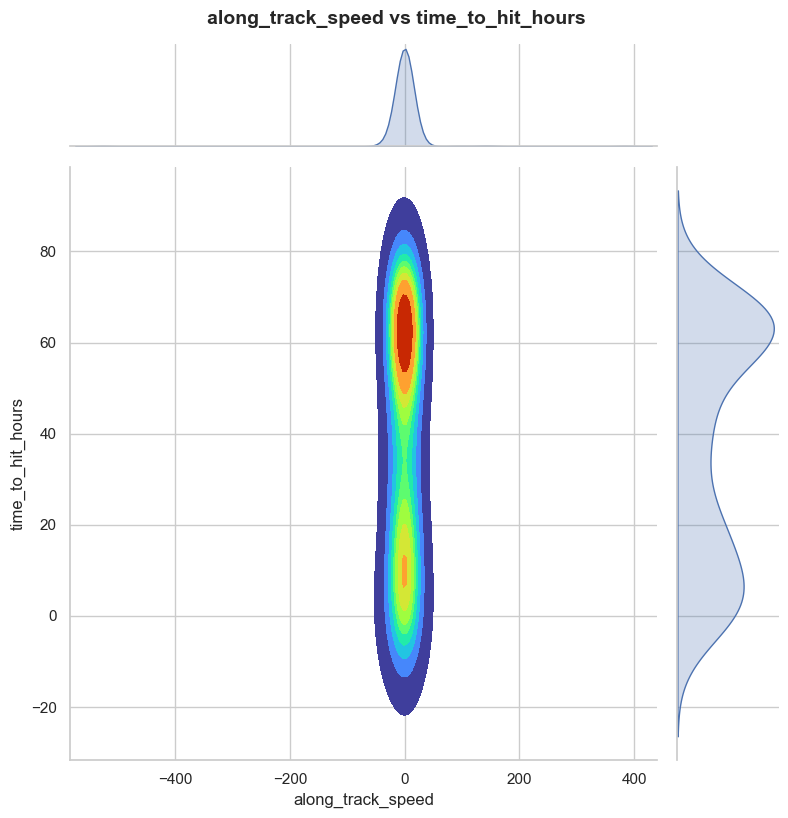

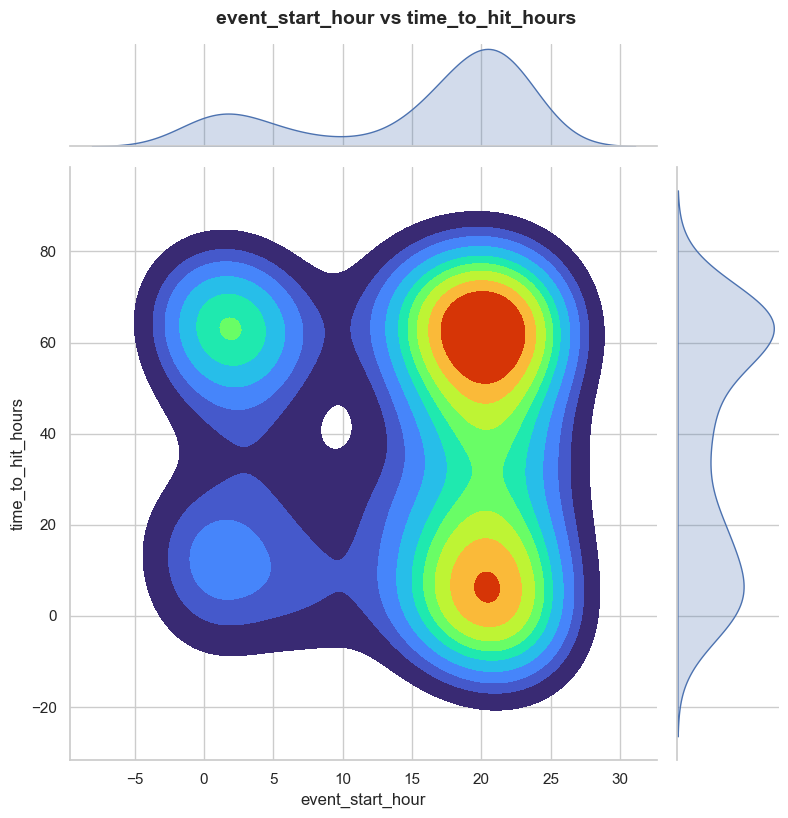

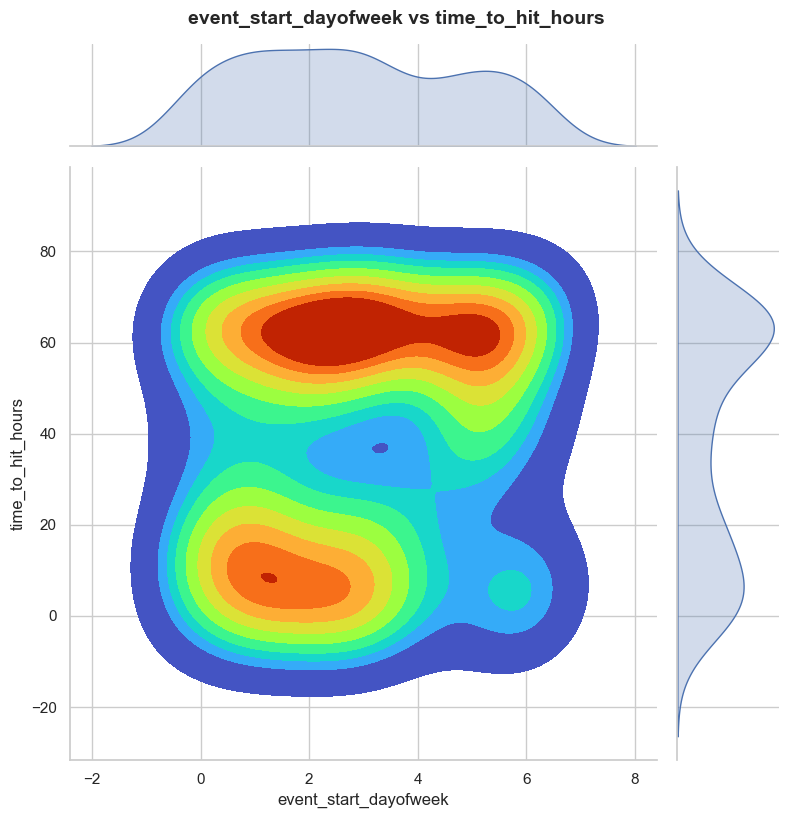

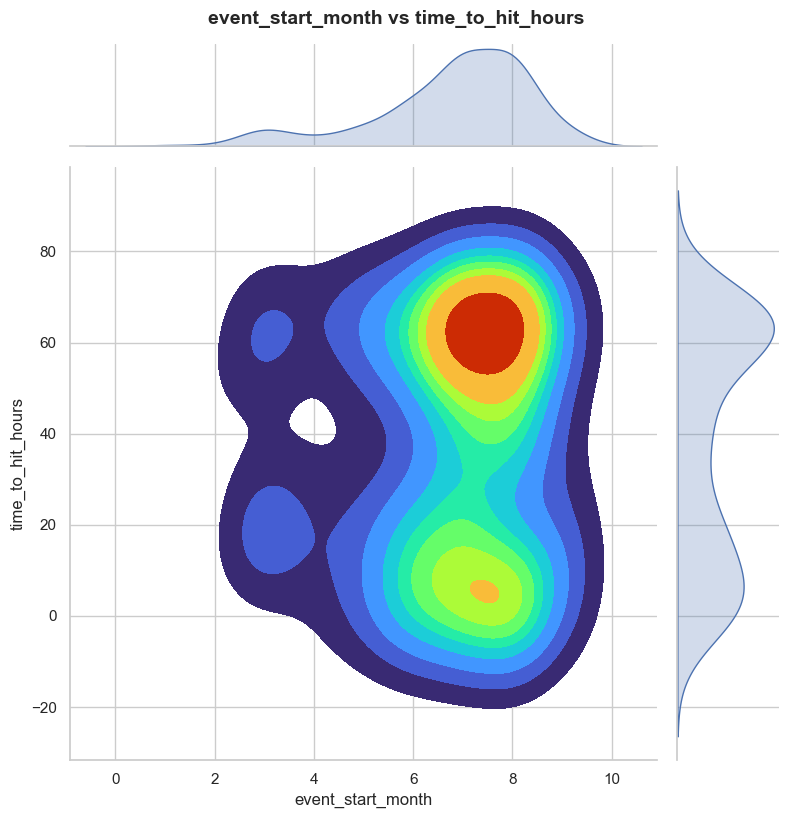

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid")

numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
exclude_cols = ["time_to_hit_hours", "event"]
features = [col for col in numeric_cols if col not in exclude_cols]

for col in features:
    if train[col].nunique() > 5:
        try:
            sns.jointplot(
                data=train,
                x=col,
                y="time_to_hit_hours",
                kind="kde",
                fill=True,
                cmap="turbo",
                height=8
            )

            plt.suptitle(f"{col} vs time_to_hit_hours", y=1.02, fontsize=14, fontweight="bold")
            plt.show()

        except Exception as e:
            print(f"Skipped {col}: {e}")